## Import all the necessary config files

In [1]:
from config import *
from utils import *

import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import random

np.random.seed(42)
random.seed(42)
#if you get an error here you propoably didn't close the parameters excel sheet

In [2]:
# model name to be included in file names later with the output_title function, creating an iteration subscript, e.g. Run_001
title = 'Run'

## Run the coral model

In [3]:
print(growth_rate_df)

   CoralType  GrowthRate_cm_per_year
0  Branching                     2.5
1    Foliose                     3.0
2      Other                     1.0


In [4]:
# This runs the model once for the number of years selected in the user input files
run_coral_model(PSD_T0, MaxYear) # no PDS_df because it’s a placeholder. It basically asks a user to link SOME data frame to it. Same as run_model_n_times(n_iterations) simply tells a user that there should be some number in those brackets that will become the number of iterations. 

,Year,Branching_Area (%),Foliose_Area (%),Other_Area (%),total_coral_cover (%)
0,0,2.600000,7.300000,8.000000,17.900000
1,1,2.515729,7.464690,7.680909,17.661328
2,2,2.537464,8.163203,8.434096,19.134763
3,3,2.712274,9.481513,8.574761,20.768549
4,4,3.067323,11.549938,9.599902,24.217163
5,5,3.429471,13.815978,9.622050,26.867499
6,6,3.726979,16.200496,9.649107,29.576583
7,7,3.888359,19.253889,10.027601,33.169848
8,8,3.824742,21.654331,10.200035,35.679107
9,9,3.740802,23.742145,9.953086,37.436033


## Plot the change in total coral cover over the years

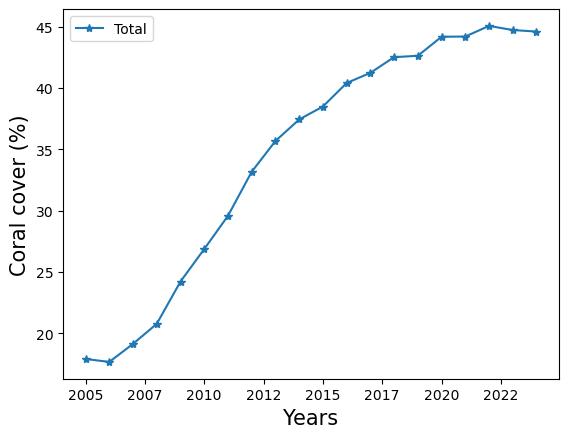

In [5]:
# Build actual years based on row count
n = len(opts.yearly_total_coral_cover_df)
actual_years = range(year_start, year_start + n)

# Plot with actual years as x-values
plt.plot(actual_years,
         opts.yearly_total_coral_cover_df['total_coral_cover (%)'],
         '-*',
         label='Total')

plt.xlabel('Years', fontsize=15)
plt.ylabel('Coral cover (%)', fontsize=15)
plt.legend()

# Make x-axis labels integers only
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## The benthic cover over the years in percentage

In [6]:
opts.yearly_benthic_cover_df

,Year,total_benthic_cover (%),available_substrate (%),hard_substrate (%),dead_coral (%),CCA (%),turfing_algae (%),macro_algae (%),rubble (%),sediment (%),total_cc,unavailable_sub,tot
0,0,89.100000,43.300000,2.400000,4.000000,0.800000,36.100000,36.800000,4.000000,5.000000,17.900000,45.800000,107.000000
1,1,82.338672,44.094227,2.206141,4.561484,0.738235,33.184035,33.958825,3.075981,4.613971,17.661328,45.133333,106.888889
2,2,80.865237,39.643680,2.127025,4.825572,0.739016,31.993999,33.994745,2.566028,4.618851,19.134763,41.136113,99.914556
3,3,79.231451,38.408220,2.039632,4.984019,0.739682,30.679471,34.025355,2.140282,4.623010,20.768549,40.751953,99.928721
4,4,75.782837,35.291451,1.854527,4.829193,0.740262,27.895177,34.052069,1.784969,4.626640,24.217163,40.431934,99.940548
5,5,73.132501,32.916736,1.713547,4.710160,0.740765,25.774596,34.075171,1.488483,4.629779,26.867499,40.166183,99.950418
6,6,70.423417,30.436718,1.570295,4.523249,0.741200,23.619855,34.095189,1.241132,4.632499,29.576583,39.945353,99.958653
7,7,66.830152,27.033712,1.381110,4.150769,0.741582,20.774203,34.112787,1.034810,4.634890,33.169848,39.761964,99.965524
8,8,64.320893,24.682130,1.246914,3.948680,0.741914,18.755658,34.128039,0.862727,4.636962,35.679107,39.610018,99.971255
9,9,62.563967,23.056063,1.139037,4.050650,0.742198,17.133013,34.141116,0.719215,4.638739,37.436033,39.483940,99.976035


## Plot the benthic cover over the years for turfing algae, dead coral, rubble, macro algae and total coral cover in percentage

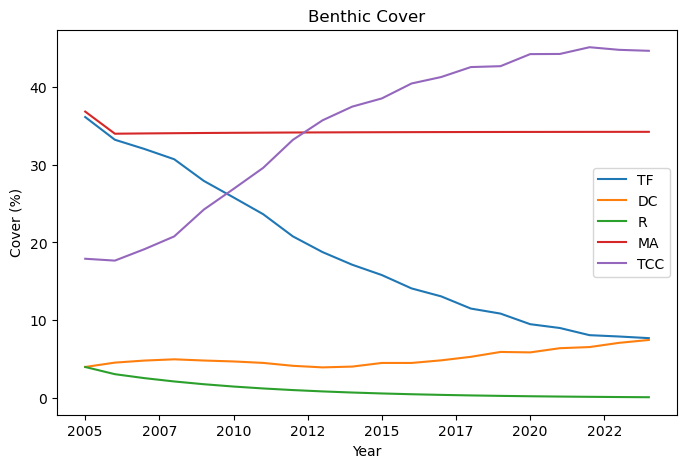

In [7]:
# Make a clean working copy and normalise column names
df = opts.yearly_benthic_cover_df.copy()
df.columns = df.columns.str.strip()

# Replace index with actual years
n = len(df)
actual_years = range(year_start, year_start + n)  # real years
df.index = pd.Index(actual_years, name="Year")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['turfing_algae (%)'], label='TF')
ax.plot(df['dead_coral (%)'], label='DC')
ax.plot(df['rubble (%)'], label='R')
ax.plot(df['macro_algae (%)'], label='MA')
ax.plot(df['total_cc'], label='TCC')

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Benthic Cover')
ax.legend()

# Force integer year labels
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## Export the data frames to excel

In [8]:
# This function exports data frames to Excel 

export_to_excel(opts.yearly_population_df_list,'yearly_population')
export_to_excel(opts.yearly_surface_area_df_list,'yearly_surface_area')
export_to_excel(opts.yearly_total_coral_cover_df,'yearly_total_coral_cover')
export_to_excel(opts.yearly_benthic_cover_df,'yearly_benthic_cover')

## Plots - please enter the years (within model range) for each plot

(6, 10, 13, 17)


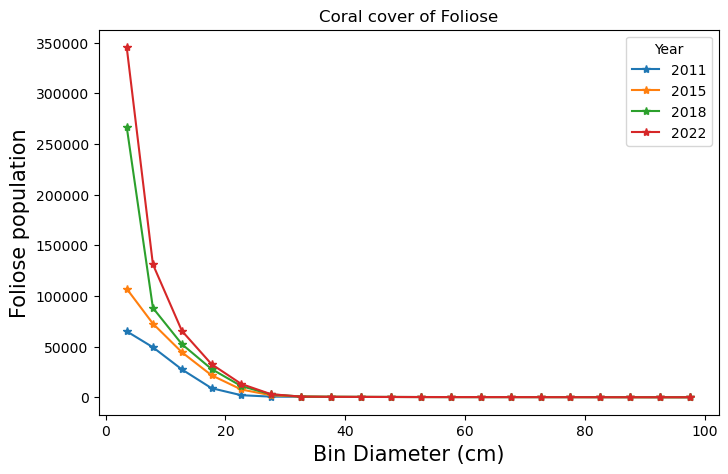

In [9]:
#Coral Cover Population

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    # Convert them to model years (indices) for the model
    model_years = tuple(year - year_start for year in Years)
    print(model_years)
    # Plot coral population change by type
    plot_coral_type_population_change('Foliose', False, *model_years)

(6, 10, 13, 17)


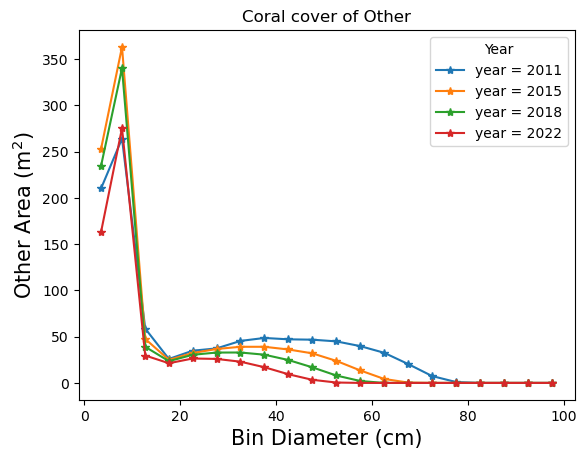

In [10]:
# This plots the Area of the coral type chosen for different input years
# Other

#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    print(model_years)

    #Plot coral area change by type
    plot_coral_type_areal_change('Other', False, *model_years)

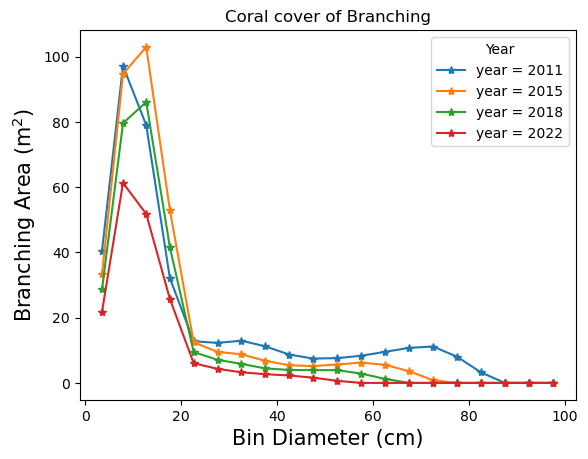

In [11]:
# This plots the Area of the coral type chosen for different input years
# Branching

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Branching', False, *model_years)

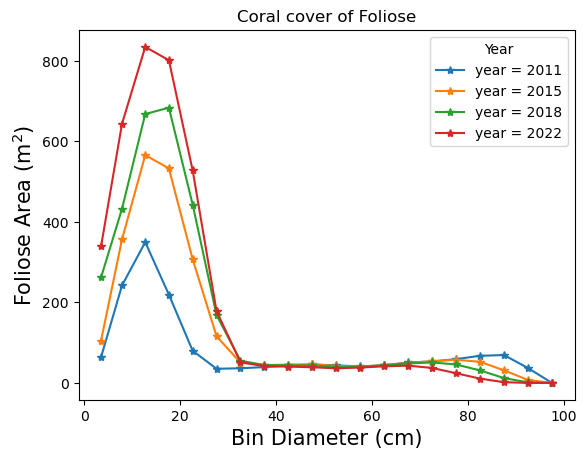

In [12]:
# This plots the Area of the coral type chosen for different input years
# Foliose

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2011, 2015, 2018, 2022

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:

    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Foliose',False, *model_years)

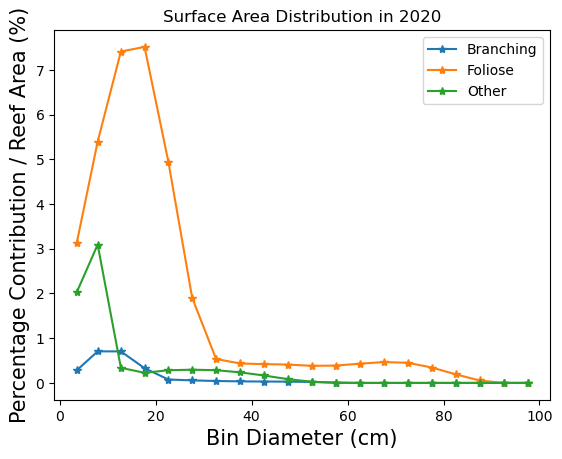

In [13]:
# Plot surface area distribution of different coral types in a given year.

Year = 2020

# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_surface_area_distribution(model_year)

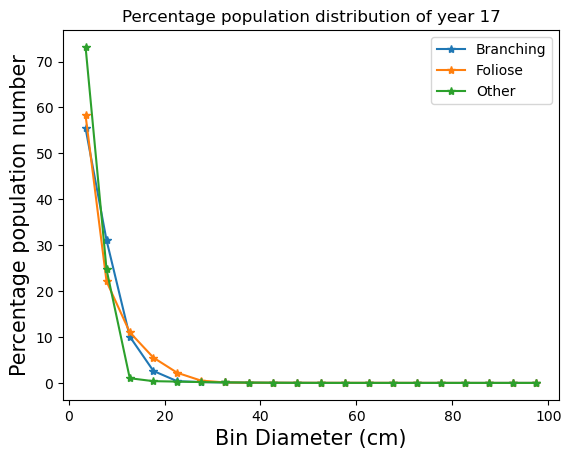

In [14]:
# This function plots the percentage population distribution of the bins in a given year. 
# plot_population_distribution_in_percentage(year)
# For example: 100*branching_population_bin_2/total_branching_population 

Year = 2022
# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_population_distribution_in_percentage(model_year)

## Rugosity

In [15]:
# This function calculates the Rugosity and returns them in a list

rugosity_list = get_rugosity_list()
export_to_excel(rugosity_list,'Rugosity')

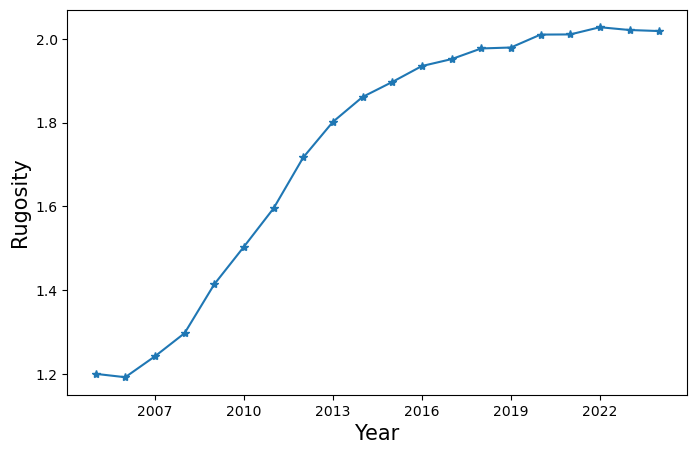

In [16]:
# This function plots the rugosity values over the years

plot_rugosity_year()

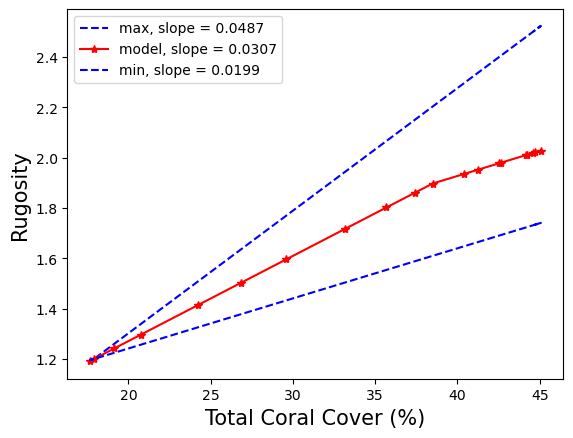

In [17]:
plot_rugosity_total_coral_cover()

## Run simulation for n number of times and plot the total coral cover

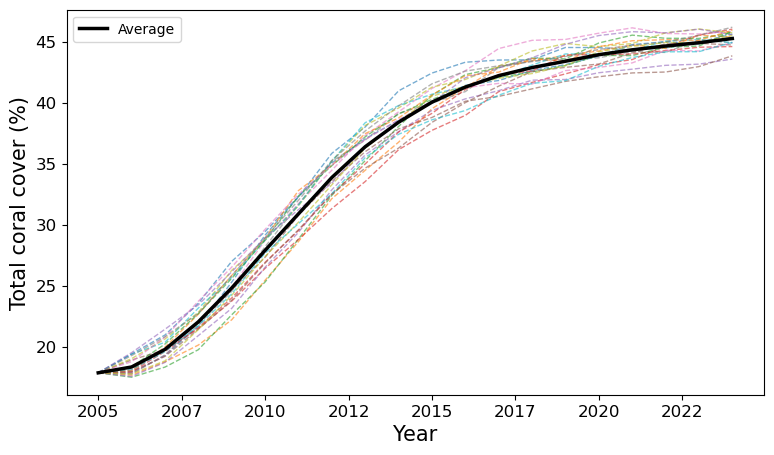

In [18]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

In [19]:
iteration_df

,year,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6,iteration_7,iteration_8,iteration_9,...,iteration_12,iteration_13,iteration_14,iteration_15,iteration_16,iteration_17,iteration_18,iteration_19,iteration_20,averaged
0,0,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,...,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000,17.900000
1,1,17.902047,17.704963,17.539497,18.127945,17.603363,18.949194,17.885522,17.803776,19.061122,...,18.082658,18.394576,17.978805,19.547466,17.996691,18.809624,19.310435,17.816504,18.167062,18.377375
2,2,19.303133,18.794362,18.368529,19.768236,18.750880,19.785132,19.311026,19.367045,20.665377,...,20.004847,20.252650,19.648404,21.463832,19.242510,20.816370,20.855208,18.874748,19.634669,19.814774
3,3,21.725173,20.171077,19.791346,21.529364,20.945145,21.979623,22.111825,21.853076,22.852721,...,22.694708,22.746898,21.602445,23.462661,21.475898,23.759639,22.760544,21.437502,21.739831,22.071707
4,4,25.321129,22.239364,22.648095,23.764185,23.174174,24.679488,24.908029,24.565802,26.285048,...,25.866117,25.624734,24.023602,26.162006,23.839230,26.547597,25.841642,24.237947,24.357386,24.840635
5,5,29.163002,25.470649,25.328394,26.445318,26.537318,27.352993,28.739309,28.218129,28.765512,...,28.915366,28.783959,26.937940,28.947842,26.880399,29.640102,28.935806,27.411515,27.691313,27.918939
6,6,32.273807,28.639731,28.843964,28.816219,29.388735,30.798574,31.743379,31.664633,31.554716,...,32.812806,32.371363,29.542065,31.256805,29.607204,32.512048,32.020899,30.220462,30.103497,30.904701
7,7,35.857304,32.149420,32.416298,31.336945,32.872654,33.559602,34.473619,35.200613,35.221858,...,34.876293,34.846732,32.520128,33.418594,32.524889,34.891431,35.275501,33.281679,32.563845,33.879032
8,8,38.014047,34.471224,35.262002,33.549726,35.727723,35.993306,37.318645,36.938974,38.137776,...,37.471258,37.205627,34.987711,36.367293,34.645317,36.982907,37.686938,36.281174,35.508136,36.398182
9,9,40.969745,36.767473,38.056586,36.155500,37.631901,37.858175,39.251736,39.118837,39.566475,...,38.750897,39.081992,37.599847,38.484687,36.285484,38.589233,39.735777,38.394945,37.411352,38.402185


In [20]:
# Real data input should be saved in the coral_data_and_custom_parameters.xlsx file
# Load the Excel file into a DataFrame

# Load Excel
real_df_raw = pd.read_excel("coral_data_and_custom_parameters.xlsx", sheet_name="Real_Cover")

# Fill + mask (returns a tuple)
real_df, created = fill_nans_columnwise(
    real_df_raw,
    year_col='Year',
    make_full_years=False,
    fallback='mean',
    return_mask=True
)

# Make Year integer-like for display
real_df['Year'] = pd.to_numeric(real_df['Year'], errors='coerce').round().astype('Int64')

value_cols = [c for c in real_df.columns if c != 'Year']

# Build red-highlight styles
styles = created.reindex_like(real_df).replace({True: 'color: red', False: ''})

# Display with exactly 2 decimals (and integer Year)
styler = (
    real_df.style
           .format({c: '{:.2f}' for c in value_cols})
           .format({'Year': '{:.0f}'})
           .apply(lambda _: styles, axis=None)
)
display(styler)


,Year,RealBranching_Area (%),RealFoliose_Area (%),RealOther_Area (%)
0,2000,1.200000,2.200000,16.300000
1,2001,1.550000,2.200000,17.400000
2,2002,1.900000,2.200000,18.500000
3,2003,3.000000,2.450000,17.400000
4,2004,4.100000,2.700000,16.300000
5,2005,6.050000,2.700000,15.200000
6,2006,8.000000,2.700000,14.100000
7,2007,10.500000,2.550000,13.500000
8,2008,13.000000,2.400000,12.900000
9,2009,14.200000,2.700000,17.200000


## Run the model through a number iterations for all parameters and export results

In [21]:
#setting seed to ensure repeatability of runs 

np.random.seed(42)
random.seed(42)

final_df, population_results, percentage_population_results, area_results = run_model_iterations_all_parameters(100)

# Create dataframes
bin_diameters = [i * binSize for i in range(MaxBinId)]
columns = ['MG', 'Year'] + [f'Bin Diameter {d} (cm)' for d in bin_diameters]
population_size_df = pd.DataFrame(population_results, columns=columns)
percentage_population_size_df = pd.DataFrame(percentage_population_results, columns=columns)
area_df = pd.DataFrame(area_results, columns=columns)
area_df.iloc[:, 2:] = (area_df.iloc[:, 2:] * 100).clip(upper=100)

# Print the dataframes - hash these out if you don't want to see them
print("Final DataFrame")
print(final_df)

print("\nPopulation Size DataFrame")
print(population_size_df)

print("\nPercentage Population Size DataFrame")
print(percentage_population_size_df)

print("\nArea DataFrame")
print(area_df)

#Export tables to Excel
run_id = "Run_" + make_run_id(output_folder)               # e.g. '20250808_01'
fname  = f"{run_id}_all_results.xlsx" 

# Define the graph directory path
graph_dir_t = r'output/tables'# '20250808_01_all_results.xlsx'

# fname = '20250808_01_all_results.xlsx'  # if you need this
path = os.path.join(graph_dir_t, fname)

# FIX: Create the directory if it doesn't exist
os.makedirs(graph_dir_t, exist_ok=True)

path   = os.path.join(graph_dir_t, fname)

final_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_final.xlsx"), index=False)
population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population.xlsx"), index=False)
percentage_population_size_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_population_percentage.xlsx"), index=False)
area_df.to_excel(os.path.join(graph_dir_t, f"{run_id}_area.xlsx"), index=False)

Final DataFrame
    Year  Branching_Area (%)  Foliose_Area (%)  Other_Area (%)  \
0      0            2.600000          7.300000        8.000000   
1      1            2.403891          7.789569        7.998505   
2      2            2.363960          8.512509        8.416553   
3      3            2.413008          9.817919        8.629749   
4      4            2.549353         12.051277        9.439740   
..   ...                 ...               ...             ...   
15    15            2.386216         35.907697        5.439874   
16    16            2.189877         37.128667        4.913991   
17    17            1.965734         37.845216        4.511494   
18    18            1.763690         38.182456        4.107701   
19    19            1.562353         38.897865        3.891677   

    total_coral_cover (%)  total_benthic_cover (%)  available_substrate (%)  \
0               17.900000                89.100000                43.300000   
1               18.191965        

## Create plots for coral cover, benthic cover and rugosity based on the multiple iteration runs

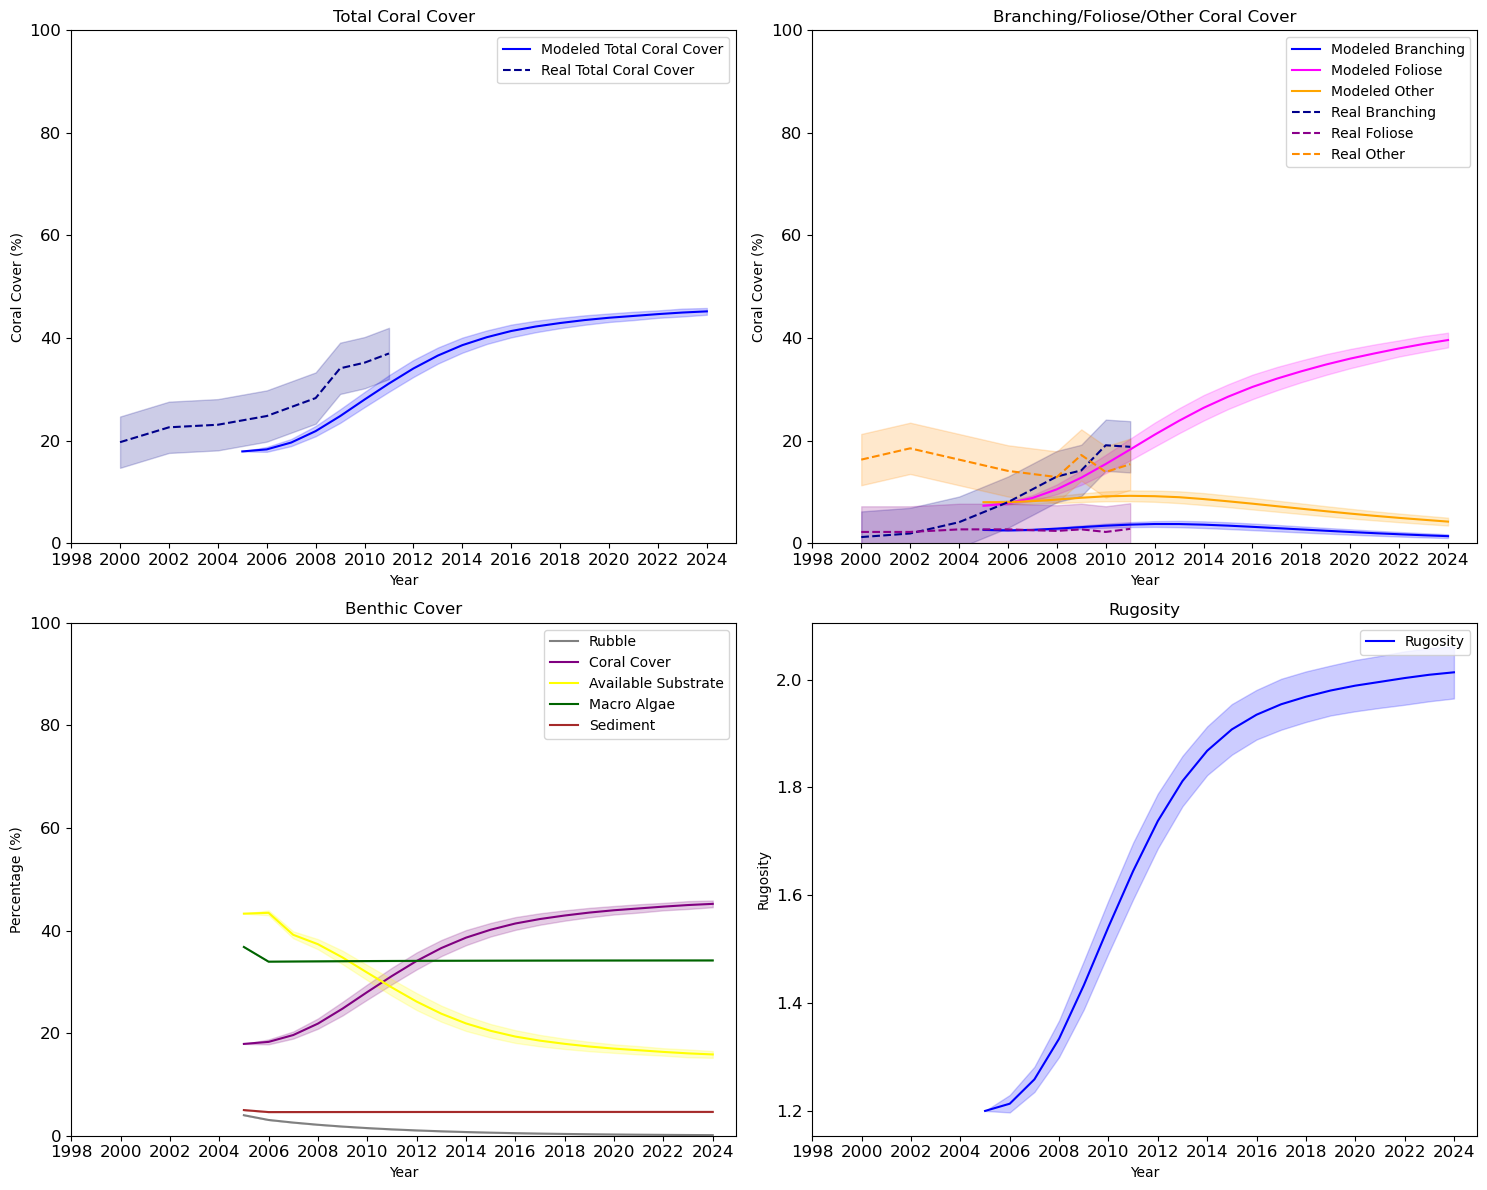

In [22]:
# Calculate the total coral cover for modelled data
final_df['Total_Coral_Cover (%)'] = final_df['Branching_Area (%)'] + final_df['Foliose_Area (%)'] + final_df['Other_Area (%)']

# Calculate the total coral cover for real data
real_df['Total_Coral_Cover (%)'] = real_df['RealBranching_Area (%)'] + real_df['RealFoliose_Area (%)'] + real_df['RealOther_Area (%)']

# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

average_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].mean()
std_dev_total = final_df.groupby('Year')['Total_Coral_Cover (%)'].std()

# Calculate the margins for real data (5% absolute above and below)
absolute_margin = 5

real_branching_margin = absolute_margin
real_foliose_margin = absolute_margin
real_other_margin = absolute_margin
real_total_margin = absolute_margin

# Create a figure with 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index

#Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Plot Total Coral Cover
axs[0, 0].plot(actual_years, average_total.astype(float), label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years, (average_total - std_dev_total).astype(float), (average_total + std_dev_total).astype(float), color='blue', alpha=0.2)
axs[0, 0].plot(real_df['Year'].astype(float), real_df['Total_Coral_Cover (%)'].astype(float), label='Real Total Coral Cover', color='darkblue', linestyle='--')
axs[0, 0].fill_between(real_df['Year'].astype(float), (real_df['Total_Coral_Cover (%)'].astype(float) - real_total_margin), (real_df['Total_Coral_Cover (%)'].astype(float) + real_total_margin), color='darkblue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()
axs[0, 0].set_ylim(0, 100)
axs[0, 0].set_xticks(actual_years)
axs[0, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Branching, Foliose, and Other Coral Cover
axs[0, 1].plot(actual_years, average_branching.astype(float), label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years, (average_branching - std_dev_branching).astype(float), (average_branching + std_dev_branching).astype(float), color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose.astype(float), label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years, (average_foliose - std_dev_foliose).astype(float), (average_foliose + std_dev_foliose).astype(float), color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other.astype(float), label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years, (average_other - std_dev_other).astype(float), (average_other + std_dev_other).astype(float), color='orange', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealBranching_Area (%)'].astype(float), label='Real Branching', color='darkblue', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealBranching_Area (%)'].astype(float) - real_branching_margin), (real_df['RealBranching_Area (%)'].astype(float) + real_branching_margin), color='darkblue', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealFoliose_Area (%)'].astype(float), label='Real Foliose', color='darkmagenta', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealFoliose_Area (%)'].astype(float) - real_foliose_margin), (real_df['RealFoliose_Area (%)'].astype(float) + real_foliose_margin), color='darkmagenta', alpha=0.2)
axs[0, 1].plot(real_df['Year'].astype(float), real_df['RealOther_Area (%)'].astype(float), label='Real Other', color='darkorange', linestyle='--')
axs[0, 1].fill_between(real_df['Year'].astype(float), (real_df['RealOther_Area (%)'].astype(float) - real_other_margin), (real_df['RealOther_Area (%)'].astype(float) + real_other_margin), color='darkorange', alpha=0.2)
axs[0, 1].set_title('Branching/Foliose/Other Coral Cover')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)
axs[0, 1].set_xticks(actual_years)
axs[0, 1].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Benthic Cover
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

#years_benthic = average_rubble.index
#actual_years_benthic = [year + year_start for year in years]

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)
axs[1, 0].set_xticks(actual_years)
axs[1, 0].set_xticklabels([f'{int(year)}' for year in actual_years])

# Plot Rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()
axs[1,1].set_xticks(actual_years)
axs[1,1].set_xticklabels([f'{int(year)}' for year in actual_years])

# After your plotting code:
# Get current x-axis limits
xlim = axs[0, 0].get_xlim()

# Create integer ticks from start to end
year_ticks = list(range(int(xlim[0]), int(xlim[1])+1, 2)) 
axs[0, 0].set_xticks(year_ticks)
axs[0, 0].set_xticklabels([str(year) for year in year_ticks])

axs[1, 0].set_xticks(year_ticks)
axs[1, 0].set_xticklabels([str(year) for year in year_ticks])

axs[0, 1].set_xticks(year_ticks)
axs[0, 1].set_xticklabels([str(year) for year in year_ticks])

axs[1, 1].set_xticks(year_ticks)
axs[1, 1].set_xticklabels([str(year) for year in year_ticks])

# Adjust layout
plt.tight_layout()

# Define the graph directory path
graph_dir = r'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the combined plot to the specified folder
graph_path = os.path.join(graph_dir, 'combined_graphs.png')
plt.savefig(graph_path)
plt.show()

## Create bubble plot for population distribution

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Actual years for display: [2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]


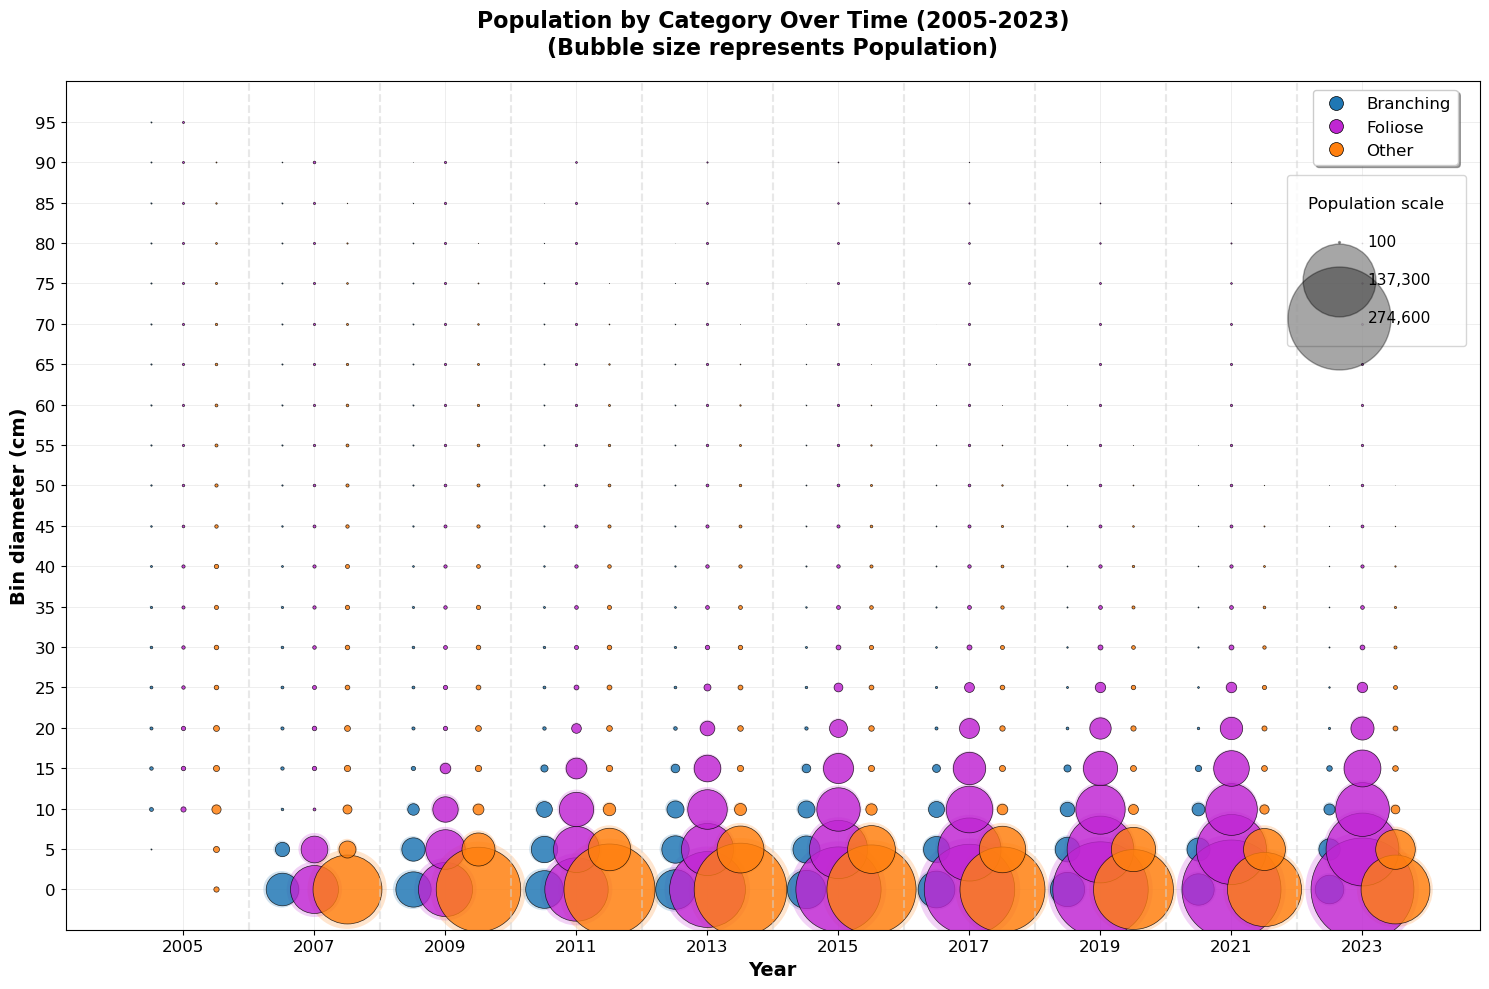

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Population by Category Over Time (2005-2023)\n(Bubble size represents Population)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [23]:
plot_bubble_chart_from_dataframe(population_size_df, 
                                title = "Population",
                                category_col="MG", 
                                year_interval=2, 
                                bubble_scale=0.02,
                                parallel_offset = 0.5,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.08,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Create bubble plot for percentage of population distribution

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Actual years for display: [2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]


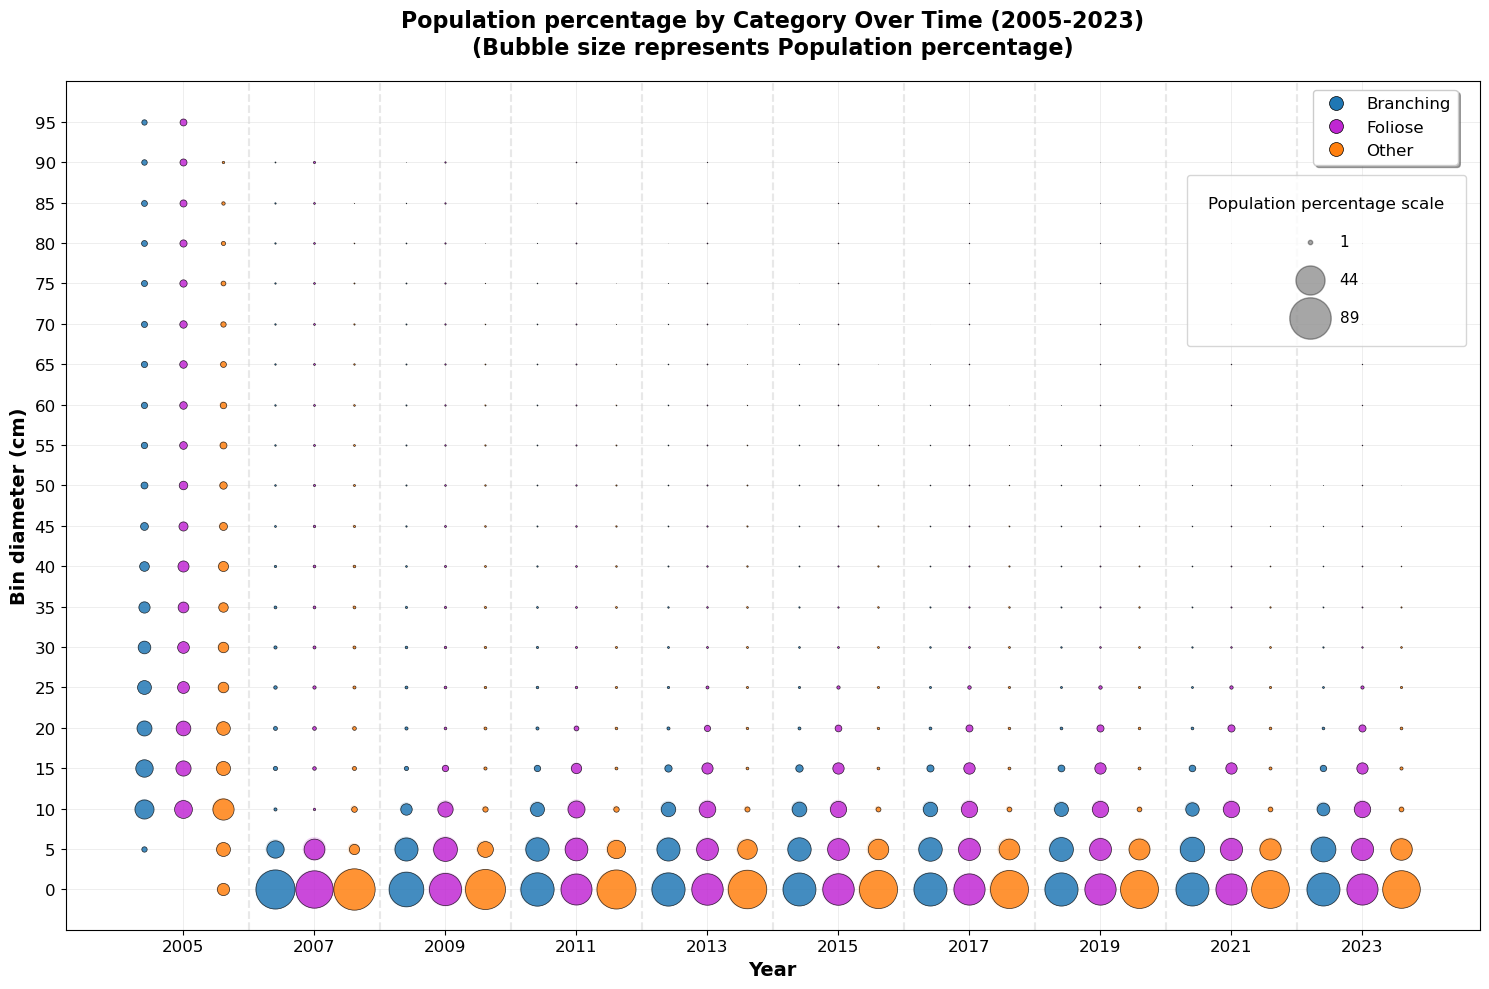

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Population percentage by Category Over Time (2005-2023)\n(Bubble size represents Population percentage)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [24]:
plot_bubble_chart_from_dataframe(percentage_population_size_df, 
                                title = "Population percentage",
                                category_col="MG", 
                                year_interval=2,  
                                bubble_scale=10,
                                parallel_offset = 0.6,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.1,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Create bubble plot for area distribution

All years in data: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Selected years (multiples of 2): [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Actual years for display: [2005, 2007, 2009, 2011, 2013, 2015, 2017, 2019, 2021, 2023]


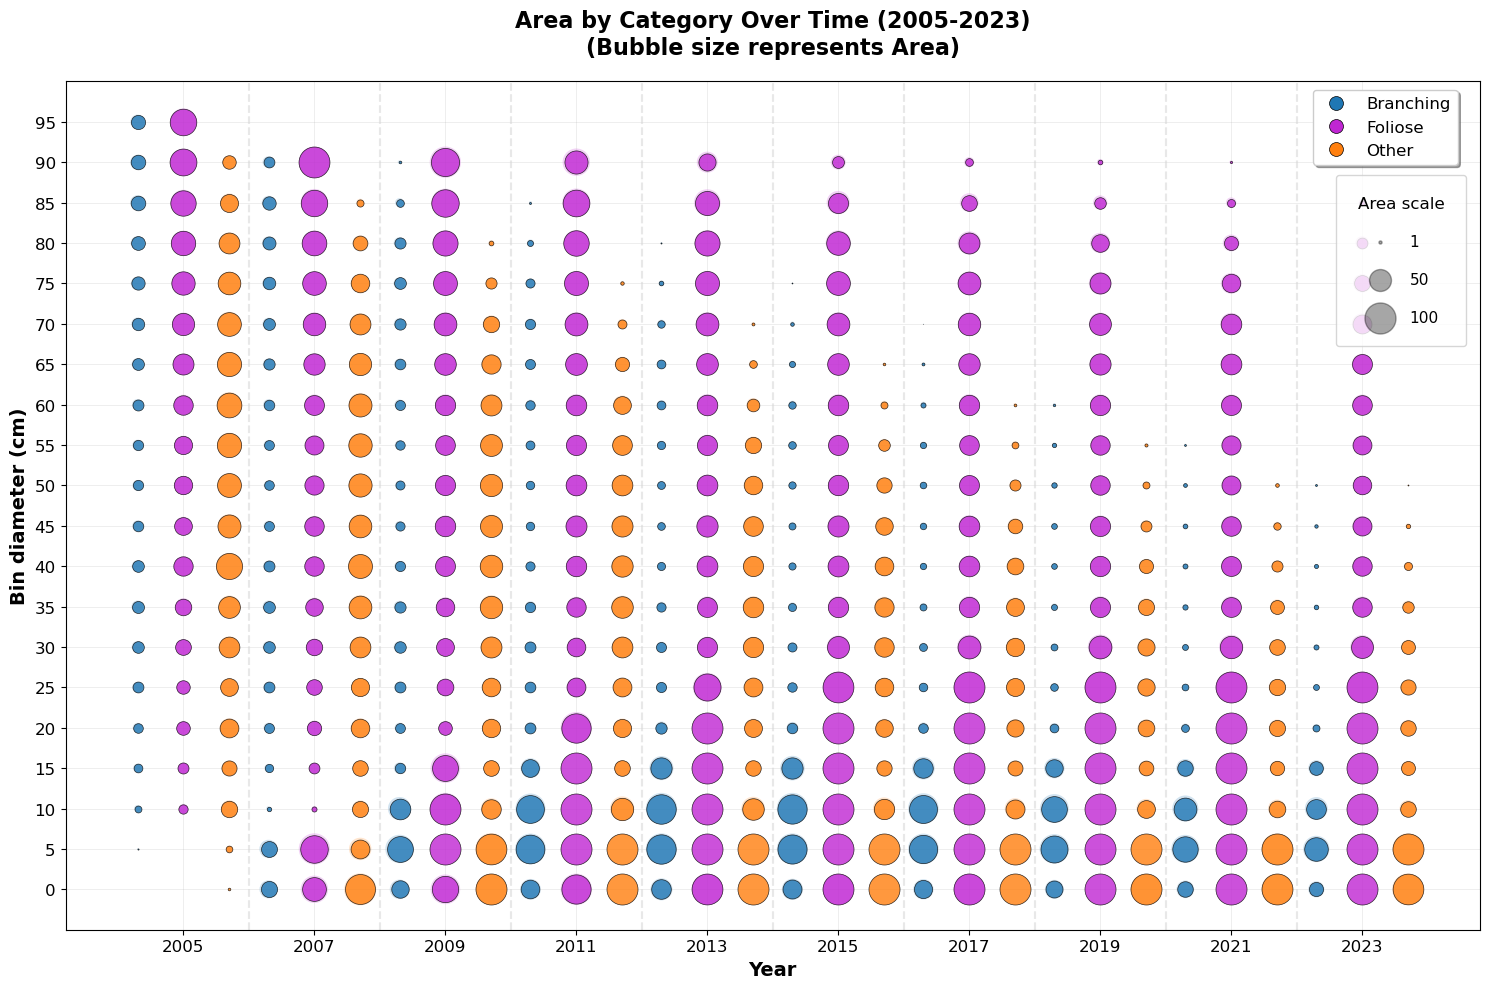

(<Figure size 1500x1000 with 1 Axes>,
 <Axes: title={'center': 'Area by Category Over Time (2005-2023)\n(Bubble size represents Area)'}, xlabel='Year', ylabel='Bin diameter (cm)'>)

In [25]:
plot_bubble_chart_from_dataframe(area_df, 
                                title = "Area",
                                category_col="MG", 
                                year_interval=2, 
                                bubble_scale=5,
                                parallel_offset = 0.7,
                                figsize=(40, 20),    # Larger plot
                                x_spacing=0.7,       # More x-spacing
                                y_spacing=5)         # More y-spacing

## Calculate and plot average and standard deviation for each morphology based on multiple iterations of model

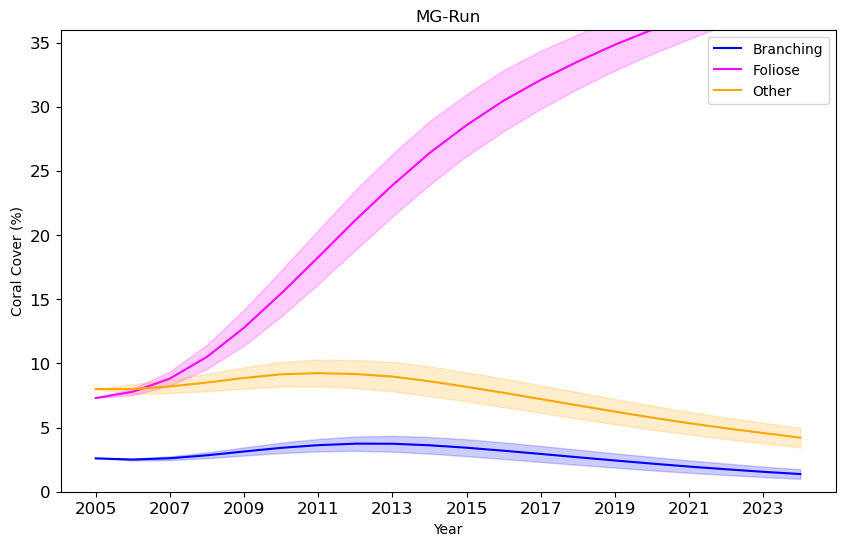

Graph has been saved to output/figures\MG-Run.png


In [26]:
# Calculate the average and standard deviation for each morphology
average_branching = final_df.groupby('Year')['Branching_Area (%)'].mean()
std_dev_branching = final_df.groupby('Year')['Branching_Area (%)'].std()

average_foliose = final_df.groupby('Year')['Foliose_Area (%)'].mean()
std_dev_foliose = final_df.groupby('Year')['Foliose_Area (%)'].std()

average_other = final_df.groupby('Year')['Other_Area (%)'].mean()
std_dev_other = final_df.groupby('Year')['Other_Area (%)'].std()

# Plot the average results with standard deviation
plt.figure(figsize=(10, 6))
# Convert model years -> actual years for x-axis
years_model = average_branching.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_branching, label='Branching', color='blue')
plt.fill_between(years, average_branching - std_dev_branching, average_branching + std_dev_branching, color='blue', alpha=0.2)

plt.plot(years, average_foliose, label='Foliose', color='fuchsia')
plt.fill_between(years, average_foliose - std_dev_foliose, average_foliose + std_dev_foliose, color='fuchsia', alpha=0.2)

plt.plot(years, average_other, label='Other', color='orange')
plt.fill_between(years, average_other - std_dev_other, average_other + std_dev_other, color='orange', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Coral Cover (%)')
plt.ylim(0, 36)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'MG-{title}')
plt.legend()

# Define the graph directory path
graph_dir = 'output/figures'

# Create the directory if it doesn't exist
os.makedirs(graph_dir, exist_ok=True)

# Save the plot to the specified folder
graph_path = os.path.join(graph_dir, f'MG-{title}.png')
plt.savefig(graph_path)
plt.show()

print(f"Graph has been saved to {graph_path}")

## Plot substrate based on multiple iterations

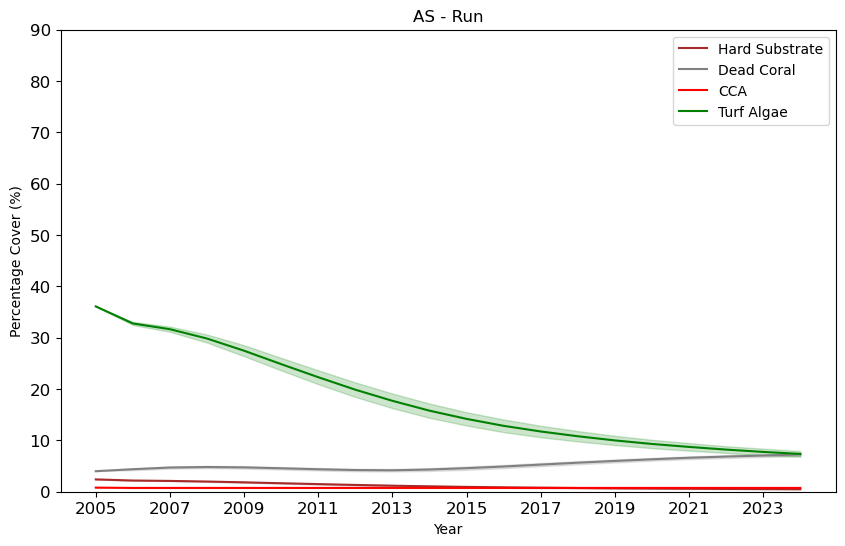

AS graph has been saved to output/figures\AS-Run.png


In [27]:
#Plot AS-title
# Calculate the average and standard deviation for each benthic cover type
average_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].mean()
std_dev_hard_substrate = final_df.groupby('Year')['hard_substrate (%)'].std()

average_dead_coral = final_df.groupby('Year')['dead_coral (%)'].mean()
std_dev_dead_coral = final_df.groupby('Year')['dead_coral (%)'].std()

average_cca = final_df.groupby('Year')['CCA (%)'].mean()
std_dev_cca = final_df.groupby('Year')['CCA (%)'].std()

average_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].mean()
std_dev_turfing_algae = final_df.groupby('Year')['turfing_algae (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))

# Convert model years -> actual years for x-axis
years_model = average_hard_substrate.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)              # make sure they’re ints

plt.plot(years, average_hard_substrate, label='Hard Substrate', color='brown')
plt.fill_between(years, average_hard_substrate - std_dev_hard_substrate, average_hard_substrate + std_dev_hard_substrate, color='brown', alpha=0.2)

plt.plot(years, average_dead_coral, label='Dead Coral', color='grey')
plt.fill_between(years, average_dead_coral - std_dev_dead_coral, average_dead_coral + std_dev_dead_coral, color='grey', alpha=0.2)

plt.plot(years, average_cca, label='CCA', color='red')
plt.fill_between(years, average_cca - std_dev_cca, average_cca + std_dev_cca, color='red', alpha=0.2)

plt.plot(years, average_turfing_algae, label='Turf Algae', color='green')
plt.fill_between(years, average_turfing_algae - std_dev_turfing_algae, average_turfing_algae + std_dev_turfing_algae, color='green', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage Cover (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'AS - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_as = os.path.join(graph_dir, f'AS-{title}.png')
plt.savefig(graph_path_as)
plt.show()

print(f"AS graph has been saved to {graph_path_as}")

## Plot benthic cover based on multiple iterations

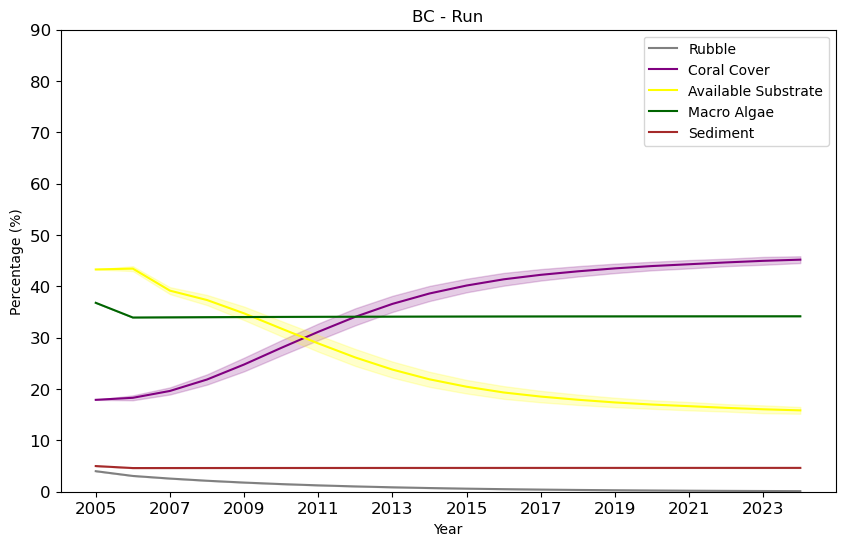

BC graph has been saved to output/figures\BC-Run.png


In [28]:
#plot benthic cover 
# Calculate the average and standard deviation for each benthic cover type
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()

average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()

average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()

average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()

average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

# Plot the average results with standard deviation for benthic cover types
plt.figure(figsize=(10, 6))
years_model = average_rubble.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int)  

plt.plot(years, average_rubble, label='Rubble', color='grey')
plt.fill_between(years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)

plt.plot(years, average_coral_cover, label='Coral Cover', color='purple')
plt.fill_between(years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)

plt.plot(years, average_as, label='Available Substrate', color='yellow')
plt.fill_between(years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)

plt.plot(years, average_ma, label='Macro Algae', color='darkgreen')
plt.fill_between(years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)

plt.plot(years, average_sediment, label='Sediment', color='brown')
plt.fill_between(years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.ylim(0, 90)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'BC - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_bc = os.path.join(graph_dir, f'BC-{title}.png')
plt.savefig(graph_path_bc)
plt.show()

print(f"BC graph has been saved to {graph_path_bc}")

## Plot rugosity based on multiple iterations

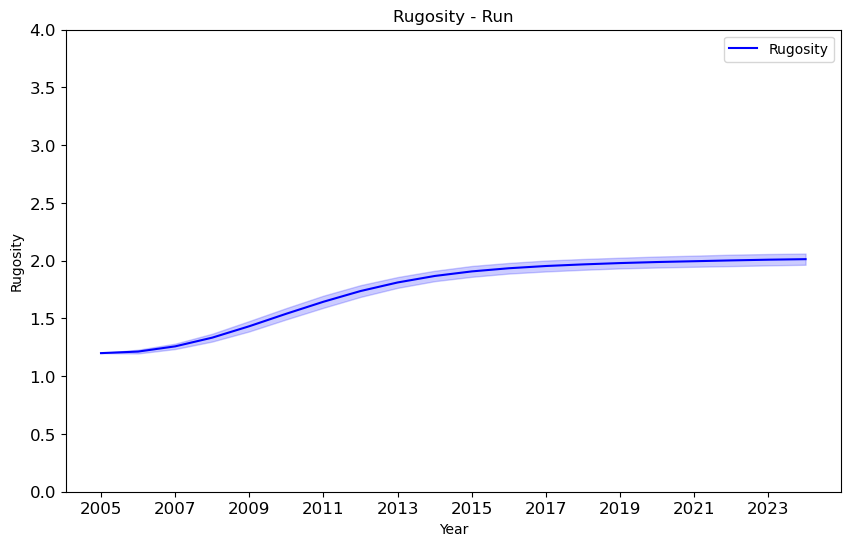

Rugosity graph has been saved to output/figures\Rugosity-Run.png


In [29]:
#plot rugosity
# Calculate the average and standard deviation for rugosity
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

# Plot the average results with standard deviation for rugosity
plt.figure(figsize=(10, 6))
years_model = average_rugosity.index.to_numpy()
if np.nanmax(years_model) < 1000:   # looks like indices 0..N-1
    years = years_model + int(year_start)
else:
    years = years_model
years_int = years.astype(int) 

plt.plot(years, average_rugosity, label='Rugosity', color='blue')
plt.fill_between(years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)

plt.xlabel('Year')
plt.ylabel('Rugosity')
plt.ylim(0, 4)
step = 2  # every 2 years
ticks = years_int[::step]
plt.xticks(ticks, [f"{y:d}" for y in ticks])
plt.title(f'Rugosity - {title}')
plt.legend()

# Save the plot to the specified folder
graph_path_rugosity = os.path.join(graph_dir, f'Rugosity-{title}.png')
plt.savefig(graph_path_rugosity)
plt.show()

print(f"Rugosity graph has been saved to {graph_path_rugosity}")

## Predicting the effect of a cyclone on the whole colony mortality

In [30]:
# This calculation does not use the existing cyclone data from the past, but rather predicts a hypothetical effect of a cyclone on the colony
# to it is possible to assess the effect even if no cyclone data exists for this location
# WCM_rates are the background whole colony mortality rates under no external stressor
# WCM_rates_during_cyclone is the calculated whole colony mortality rates during cyclone

cyclone = True
cyclone_severity_level = 1
distance_to_cyclone = 106

WCM_rates_during_cyclone = get_WCM_rates_after_cyclones(WCM_rates, cyclone_severity_level, distance_to_cyclone)
WCM_rates_during_cyclone

,Branching,Foliose,Other
0,0.200,0.20,0.20
1,0.148,0.04,0.04
2,0.148,0.04,0.04
3,0.076,0.04,0.04
4,0.076,0.02,0.02
5,0.076,0.02,0.02
6,0.076,0.02,0.02
7,0.076,0.02,0.02
8,0.076,0.02,0.02
9,0.076,0.02,0.02


## The effect of bleaching on the partial colony mortality

In [31]:
# PCM_rates are the background partial colony mortality rates under no external stressor
# PCM_rates_during_bleaching is the calculated partial colony mortality rates during bleaching event

branching_bleaching_rate = 34
foliose_bleaching_rate = 17
other_bleaching_rate = 17

dhw = 8

PCM_rates_during_bleaching = get_PCM_rates_after_dhw(PCM_rates, dhw, branching_bleaching_rate, foliose_bleaching_rate, other_bleaching_rate)
PCM_rates_during_bleaching

,Branching,Foliose,Other
0,0.030115,0.058282,0.058282
1,0.034776,0.066996,0.066996
2,0.040335,0.077298,0.077298
3,0.046991,0.089494,0.089494
4,0.054986,0.103949,0.103949
5,0.064618,0.121082,0.121082
6,0.076247,0.141367,0.141367
7,0.090311,0.165327,0.165327
8,0.107326,0.193507,0.193507
9,0.127892,0.226442,0.226442


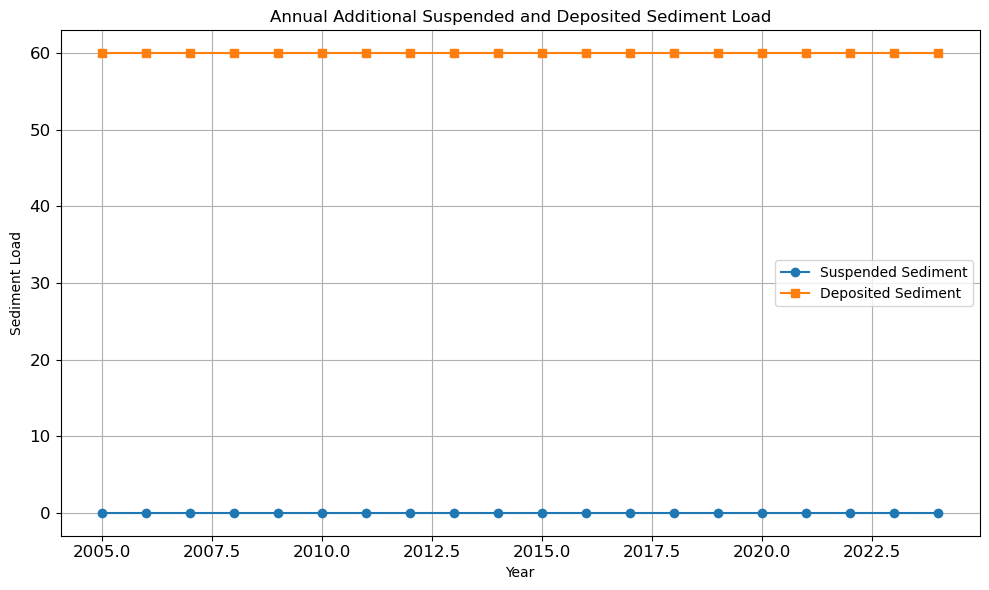

In [32]:
import matplotlib.pyplot as plt

# Build lists of years and sediment values
years = list(range(year_start, year_end + 1))
model_years = [y - year_start for y in years]

suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]

plt.figure(figsize=(10, 6))
plt.plot(years, suspended, label='Suspended Sediment', marker='o')
plt.plot(years, deposited, label='Deposited Sediment', marker='s')
plt.xlabel('Year')
plt.ylabel('Sediment Load')
plt.title('Annual Additional Suspended and Deposited Sediment Load')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
#Rio testing 
# Example usage: print the adjusted growth rates DataFrame for a specific year

# Choose the year you want to inspect (e.g., year 0)
year = 0

# Call the function to get the adjusted growth rates DataFrame
growth_rate_ss = get_GR_after_ss(
    growth_rate,              # your base growth rate DataFrame
    add_sedi_exp_per_year,    # your sediment exposure dictionary
    year,                     # the year index you want
    sedi_exp_growth_coeff         # your sediment susceptibility coefficients
)

# Print the DataFrame
print(growth_rate_ss)

    Branching  Foliose  Other
0        5.00    6.000  2.000
1        5.00    6.000  2.000
2        4.83    5.796  1.932
3        4.66    5.592  1.864
4        4.49    5.388  1.796
5        4.32    5.184  1.728
6        4.15    4.980  1.660
7        3.98    4.776  1.592
8        3.81    4.572  1.524
9        3.64    4.368  1.456
10       3.47    4.164  1.388
11       3.30    3.960  1.320
12       3.13    3.756  1.252
13       2.96    3.552  1.184
14       2.79    3.348  1.116
15       2.62    3.144  1.048
16       2.45    2.940  0.980
17       2.28    2.736  0.912
18       2.11    2.532  0.844
19       1.94    2.328  0.776


In [34]:
# Choose the year you want to inspect (e.g., year 0)
year = 0

# Call the function to get the adjusted PCM rates DataFrame
pcm_rates_ds = get_PCM_rates_after_DS_exp(
    PCM_rates,             # your base PCM rates DataFrame
    add_sedi_exp_per_year, # your sediment exposure dictionary
    year,                  # the year index you want
    sedi_exp_PCM_coeff     # your sediment PCM coefficients
)

# Print the DataFrame
print(pcm_rates_ds)

    Branching   Foliose     Other
0    0.092563  0.043557  0.098817
1    0.092591  0.043576  0.098836
2    0.092619  0.043596  0.098856
3    0.092647  0.043616  0.098876
4    0.092675  0.043636  0.098896
5    0.092703  0.043656  0.098916
6    0.092730  0.043676  0.098936
7    0.092758  0.043696  0.098956
8    0.092786  0.043716  0.098976
9    0.092814  0.043736  0.098996
10   0.092842  0.043756  0.099016
11   0.092870  0.043775  0.099035
12   0.092898  0.043795  0.099055
13   0.092925  0.043815  0.099075
14   0.092953  0.043835  0.099095
15   0.092981  0.043855  0.099115
16   0.093009  0.043875  0.099135
17   0.093037  0.043895  0.099155
18   0.093065  0.043915  0.099175
19   0.093075  0.043920  0.099180


In [35]:
from pprint import pprint
import pandas as pd

names = [
    'sediment_df',
    'sediment_years',
    'add_sedi_exp_per_year',
    'suspended',
    'deposited',
    'sedi_exp_growth_coeff',
    'sedi_exp_PCM_coeff'
]

def _print_var(name):
    g = globals()
    print(f"\n=== {name} ===")
    if name in g:
        val = g[name]
        try:
            if isinstance(val, pd.DataFrame):
                # show the dataframe (first rows) for readability
                display(val.head())
                return
        except Exception:
            pass
        pprint(val)
    else:
        print("NOT FOUND")

# If suspended/deposited are not defined but add_sedi_exp_per_year + year range exist, build them
if 'add_sedi_exp_per_year' in globals() and (('suspended' not in globals()) or ('deposited' not in globals())):
    if 'year_start' in globals() and 'year_end' in globals():
        years = list(range(year_start, year_end + 1))
        model_years = [y - year_start for y in years]
        suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
        deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]
        # attach to globals so the subsequent prints find them
        globals()['suspended'] = suspended
        globals()['deposited'] = deposited

for n in names:
    _print_var(n)


=== sediment_df ===


,Year,Month,Suspended_sediment,Deposited_sediment
0,2005,1,0,15
1,2005,2,0,15
2,2005,3,0,15
3,2005,4,0,15
4,2005,5,0,15



=== sediment_years ===
NOT FOUND

=== add_sedi_exp_per_year ===
{0: (0.0, 60.0),
 1: (0.0, 60.0),
 2: (0.0, 60.0),
 3: (0.0, 60.0),
 4: (0.0, 60.0),
 5: (0.0, 60.0),
 6: (0.0, 60.0),
 7: (0.0, 60.0),
 8: (0.0, 60.0),
 9: (0.0, 60.0),
 10: (0.0, 60.0),
 11: (0.0, 60.0),
 12: (0.0, 60.0),
 13: (0.0, 60.0),
 14: (0.0, 60.0),
 15: (0.0, 60.0),
 16: (0.0, 60.0),
 17: (0.0, 60.0),
 18: (0.0, 60.0),
 19: (0.0, 60.0)}

=== suspended ===
[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

=== deposited ===
[60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0,
 60.0]

=== sedi_exp_growth_coeff ===
{'Branching': -0.00997, 'Foliose': -0.00272, 'Other': -0.00533}

=== sedi_exp_PCM_coeff ===
{'Branching': 0.00154, 'Foliose': 0.000724, 'Other': 0.001645}


In [36]:
from pprint import pprint

# Print `additional_sediment_exposure` if present; otherwise fall back to known variables
# (relies on `pprint` imported in another cell)

if 'additional_sediment_exposure' in globals():
    print("additional_sediment_exposure:")
    pprint(globals()['additional_sediment_exposure'])

else:
    print("additional_sediment_exposure not found and cannot be constructed from available data.")

additional_sediment_exposure:
{(0, 1): (0.0, 5),
 (0, 2): (0.0, 5),
 (0, 3): (0.0, 5),
 (0, 4): (0.0, 5),
 (0, 5): (0.0, 5),
 (0, 6): (0.0, 5),
 (0, 7): (0.0, 5),
 (0, 8): (0.0, 5),
 (0, 9): (0.0, 5),
 (0, 10): (0.0, 5),
 (0, 11): (0.0, 5),
 (0, 12): (0.0, 5),
 (1, 1): (0.0, 5),
 (1, 2): (0.0, 5),
 (1, 3): (0.0, 5),
 (1, 4): (0.0, 5),
 (1, 5): (0.0, 5),
 (1, 6): (0.0, 5),
 (1, 7): (0.0, 5),
 (1, 8): (0.0, 5),
 (1, 9): (0.0, 5),
 (1, 10): (0.0, 5),
 (1, 11): (0.0, 5),
 (1, 12): (0.0, 5),
 (2, 1): (0.0, 5),
 (2, 2): (0.0, 5),
 (2, 3): (0.0, 5),
 (2, 4): (0.0, 5),
 (2, 5): (0.0, 5),
 (2, 6): (0.0, 5),
 (2, 7): (0.0, 5),
 (2, 8): (0.0, 5),
 (2, 9): (0.0, 5),
 (2, 10): (0.0, 5),
 (2, 11): (0.0, 5),
 (2, 12): (0.0, 5),
 (3, 1): (0.0, 5),
 (3, 2): (0.0, 5),
 (3, 3): (0.0, 5),
 (3, 4): (0.0, 5),
 (3, 5): (0.0, 5),
 (3, 6): (0.0, 5),
 (3, 7): (0.0, 5),
 (3, 8): (0.0, 5),
 (3, 9): (0.0, 5),
 (3, 10): (0.0, 5),
 (3, 11): (0.0, 5),
 (3, 12): (0.0, 5),
 (4, 1): (0.0, 5),
 (4, 2): (0.0, 5),
 (4, 3):

In [37]:
# Print growth_rate_ss if it exists
if 'growth_rate_ss' in globals():
    print(growth_rate_ss)
else:
    print("growth_rate_ss not found")

    Branching  Foliose  Other
0        5.00    6.000  2.000
1        5.00    6.000  2.000
2        4.83    5.796  1.932
3        4.66    5.592  1.864
4        4.49    5.388  1.796
5        4.32    5.184  1.728
6        4.15    4.980  1.660
7        3.98    4.776  1.592
8        3.81    4.572  1.524
9        3.64    4.368  1.456
10       3.47    4.164  1.388
11       3.30    3.960  1.320
12       3.13    3.756  1.252
13       2.96    3.552  1.184
14       2.79    3.348  1.116
15       2.62    3.144  1.048
16       2.45    2.940  0.980
17       2.28    2.736  0.912
18       2.11    2.532  0.844
19       1.94    2.328  0.776


In [38]:
##PLOTS TO COMPARE


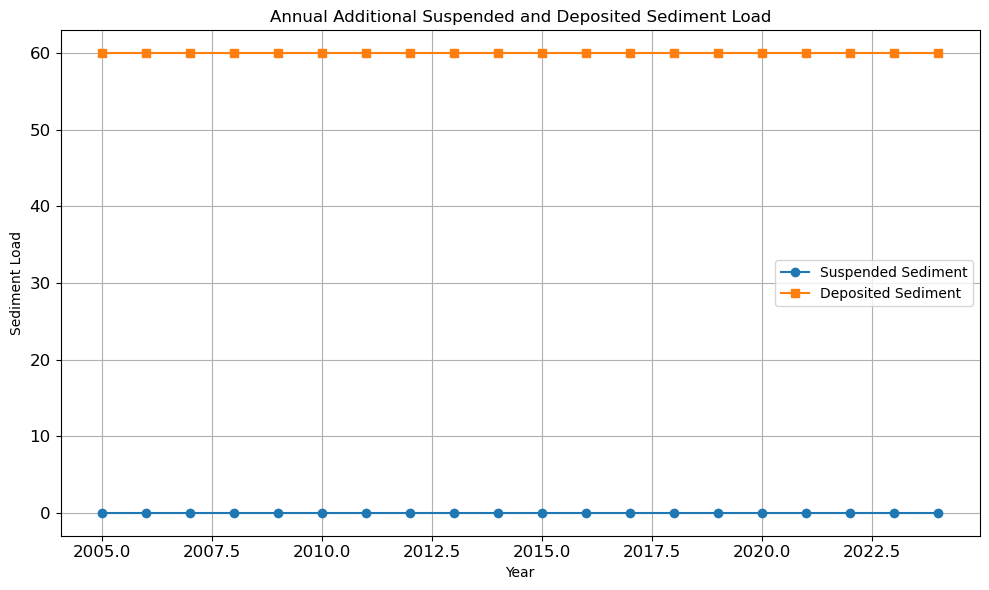

In [39]:
import matplotlib.pyplot as plt

# Build lists of years and sediment values
years = list(range(year_start, year_end + 1))
model_years = [y - year_start for y in years]

suspended = [add_sedi_exp_per_year.get(y, (0, 0))[0] for y in model_years]
deposited = [add_sedi_exp_per_year.get(y, (0, 0))[1] for y in model_years]

plt.figure(figsize=(10, 6))
plt.plot(years, suspended, label='Suspended Sediment', marker='o')
plt.plot(years, deposited, label='Deposited Sediment', marker='s')
plt.xlabel('Year')
plt.ylabel('Sediment Load')
plt.title('Annual Additional Suspended and Deposited Sediment Load')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

x= 2005
x= 2006
x= 2007
x= 2008
x= 2009
x= 2010
x= 2011
x= 2012
x= 2013
x= 2014
x= 2015
x= 2016
x= 2017
x= 2018
x= 2019
x= 2020
x= 2021
x= 2022
x= 2023
x= 2024


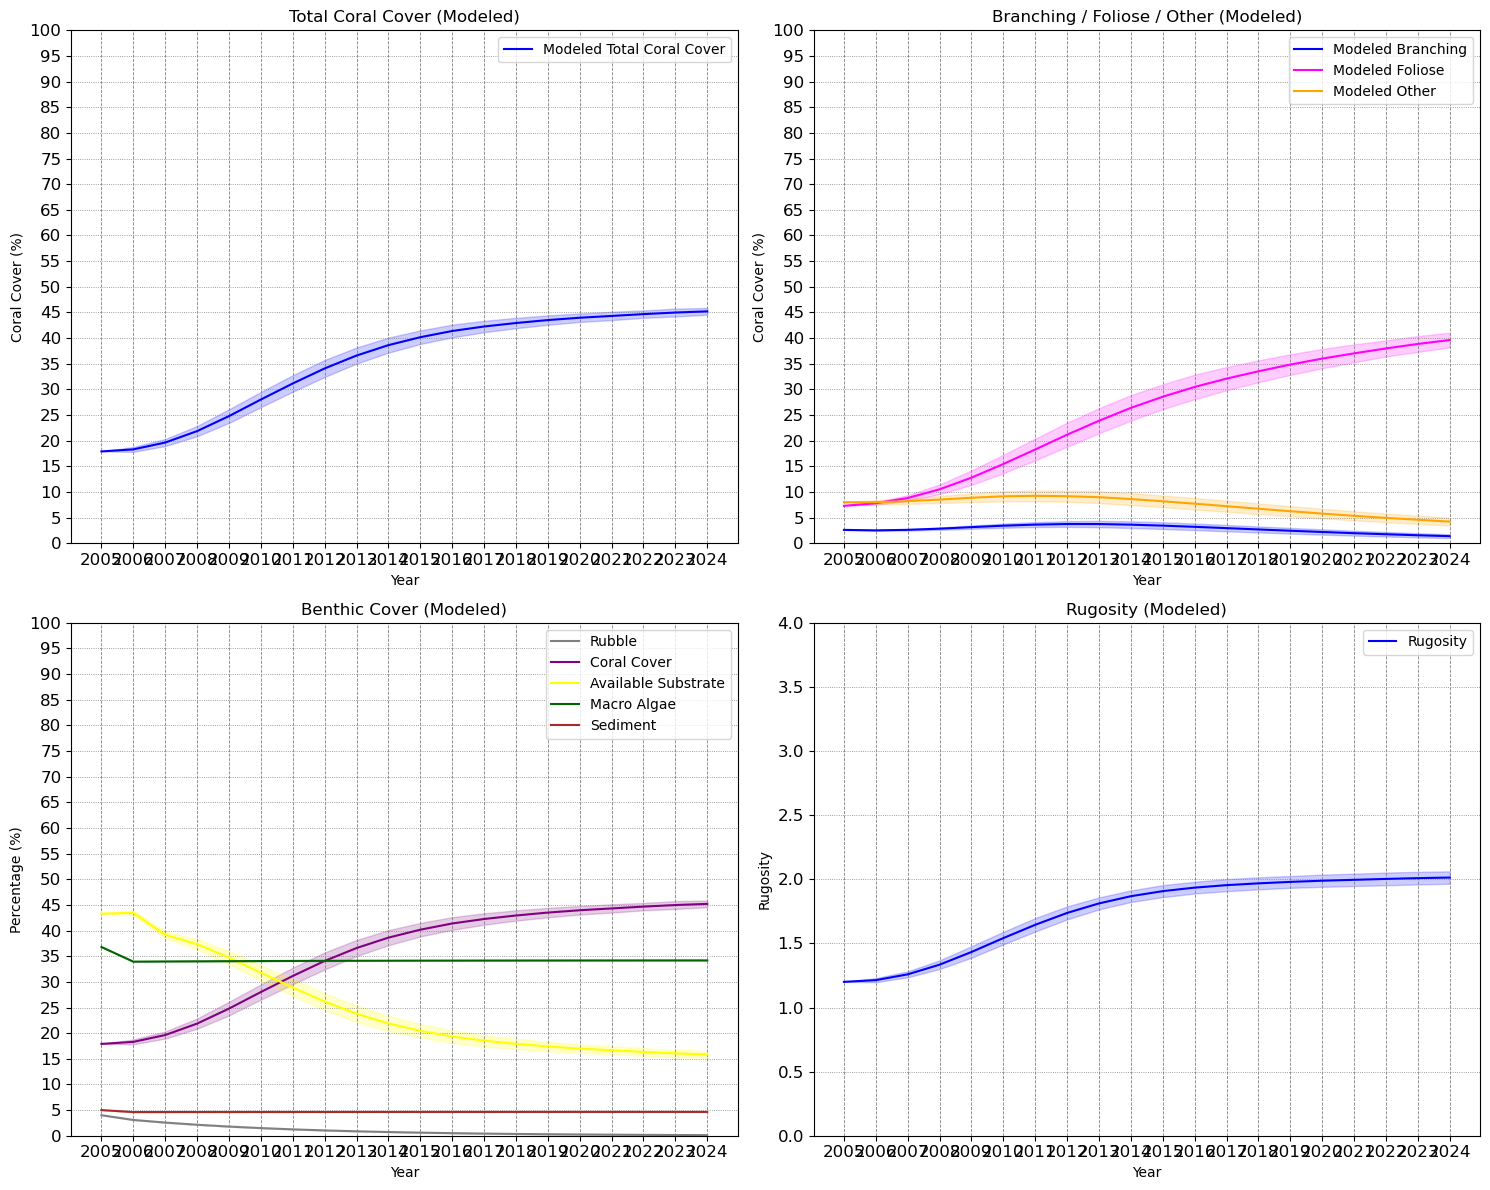

In [40]:
# ...existing code...
# Create a figure with 2x2 subplots (MODELED ONLY - real data plotting removed)
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index
# Convert model years to actual years for plotting:
actual_years = [year + year_start for year in years]

# Print yearly guidelines (console) in the requested "x=" format
for yy in actual_years:
    print(f"x= {yy}")

# Helper: vertical yearly guidelines and common x ticks
for ax in axs.flat:
    ax.set_xticks(actual_years)
    ax.set_xticklabels([f'{int(year)}' for year in actual_years])
    ax.grid(axis='x', which='major', linestyle='--', color='gray', linewidth=0.6)

# --- Plot Total Coral Cover (modeled only)
axs[0, 0].plot(actual_years, average_total.astype(float), label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years,
                       (average_total - std_dev_total).astype(float),
                       (average_total + std_dev_total).astype(float),
                       color='blue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover (Modeled)')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()
axs[0, 0].set_ylim(0, 100)

# --- Plot Branching, Foliose, Other (modeled only)
axs[0, 1].plot(actual_years, average_branching.astype(float), label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years,
                       (average_branching - std_dev_branching).astype(float),
                       (average_branching + std_dev_branching).astype(float),
                       color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose.astype(float), label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years,
                       (average_foliose - std_dev_foliose).astype(float),
                       (average_foliose + std_dev_foliose).astype(float),
                       color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other.astype(float), label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years,
                       (average_other - std_dev_other).astype(float),
                       (average_other + std_dev_other).astype(float),
                       color='orange', alpha=0.2)
axs[0, 1].set_title('Branching / Foliose / Other (Modeled)')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)

# --- Plot Benthic Cover (modeled only)
average_rubble = final_df.groupby('Year')['rubble (%)'].mean()
std_dev_rubble = final_df.groupby('Year')['rubble (%)'].std()
average_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].mean()
std_dev_coral_cover = final_df.groupby('Year')['total_coral_cover (%)'].std()
average_as = final_df.groupby('Year')['available_substrate (%)'].mean()
std_dev_as = final_df.groupby('Year')['available_substrate (%)'].std()
average_ma = final_df.groupby('Year')['macro_algae (%)'].mean()
std_dev_ma = final_df.groupby('Year')['macro_algae (%)'].std()
average_sediment = final_df.groupby('Year')['sediment (%)'].mean()
std_dev_sediment = final_df.groupby('Year')['sediment (%)'].std()

axs[1, 0].plot(actual_years, average_rubble, label='Rubble', color='grey')
axs[1, 0].fill_between(actual_years, average_rubble - std_dev_rubble, average_rubble + std_dev_rubble, color='grey', alpha=0.2)
axs[1, 0].plot(actual_years, average_coral_cover, label='Coral Cover', color='purple')
axs[1, 0].fill_between(actual_years, average_coral_cover - std_dev_coral_cover, average_coral_cover + std_dev_coral_cover, color='purple', alpha=0.2)
axs[1, 0].plot(actual_years, average_as, label='Available Substrate', color='yellow')
axs[1, 0].fill_between(actual_years, average_as - std_dev_as, average_as + std_dev_as, color='yellow', alpha=0.2)
axs[1, 0].plot(actual_years, average_ma, label='Macro Algae', color='darkgreen')
axs[1, 0].fill_between(actual_years, average_ma - std_dev_ma, average_ma + std_dev_ma, color='darkgreen', alpha=0.2)
axs[1, 0].plot(actual_years, average_sediment, label='Sediment', color='brown')
axs[1, 0].fill_between(actual_years, average_sediment - std_dev_sediment, average_sediment + std_dev_sediment, color='brown', alpha=0.2)
axs[1, 0].set_title('Benthic Cover (Modeled)')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Percentage (%)')
axs[1, 0].legend()
axs[1, 0].set_ylim(0, 100)

# --- Plot Rugosity (modeled only)
average_rugosity = final_df.groupby('Year')['Rugosity'].mean()
std_dev_rugosity = final_df.groupby('Year')['Rugosity'].std()

axs[1, 1].plot(actual_years, average_rugosity, label='Rugosity', color='blue')
axs[1, 1].fill_between(actual_years, average_rugosity - std_dev_rugosity, average_rugosity + std_dev_rugosity, color='blue', alpha=0.2)
axs[1, 1].set_title('Rugosity (Modeled)')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('Rugosity')
axs[1, 1].legend()

# --- Y-axis guidelines: 5-unit increments for percentage plots, 0.5 for rugosity
import numpy as np
import math

y_ticks_pct = np.arange(0, 101, 5)
for ax in (axs[0,0], axs[0,1], axs[1,0]):
    ax.set_yticks(y_ticks_pct)
    ax.grid(axis='y', which='major', linestyle=':', color='gray', linewidth=0.6)

ymin, ymax = axs[1,1].get_ylim()
upper = max(4.0, math.ceil(ymax / 0.5) * 0.5)
rug_ticks = np.arange(0.0, upper + 1e-9, 0.5)
axs[1,1].set_yticks(rug_ticks)
axs[1,1].grid(axis='y', which='major', linestyle=':', color='gray', linewidth=0.6)

plt.tight_layout()
graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)
graph_path = os.path.join(graph_dir, 'combined_graphs_modeled.png')
plt.savefig(graph_path)
plt.show()

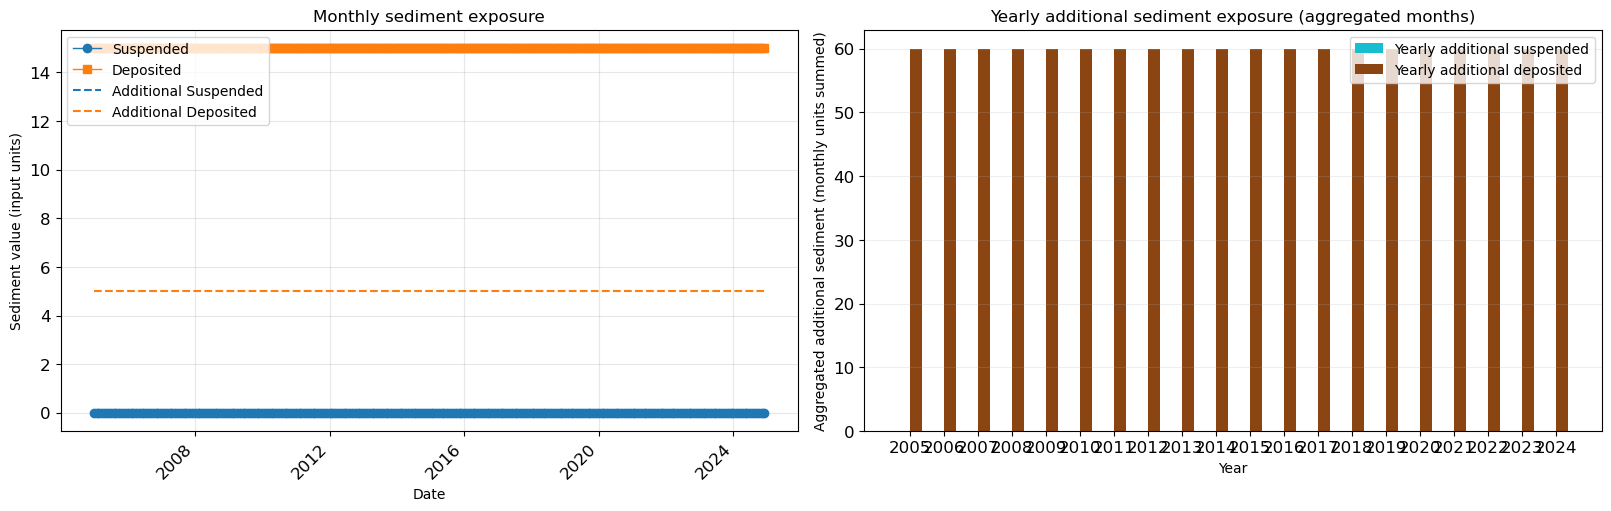


Yearly totals (suspended, deposited, added_suspended, added_deposited):


,Suspended,Deposited,Add_Suspended,Add_Deposited
Year,,,,
2005,0,180,0.0,60
2006,0,180,0.0,60
2007,0,180,0.0,60
2008,0,180,0.0,60
2009,0,180,0.0,60
2010,0,180,0.0,60
2011,0,180,0.0,60
2012,0,180,0.0,60
2013,0,180,0.0,60


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import os

# safe fallbacks if variables not present
sedi_dict = globals().get('sedi_years', {})
baseline_suspended = globals().get('baseline_suspended_sediment', 0)
baseline_deposited = globals().get('baseline_deposited_sediment', 0)
ys = []

for (rel_year, month), vals in sedi_dict.items():
    try:
        suspended, deposited = vals
    except Exception:
        suspended, deposited = (0.0, 0.0)
    year = int(rel_year) + int(year_start)
    date = datetime(year, int(month), 1)
    add_s = max(0.0, suspended - baseline_suspended)
    add_d = max(0.0, deposited - baseline_deposited)
    ys.append({
        "date": date,
        "Year": year,
        "Month": int(month),
        "Suspended": suspended,
        "Deposited": deposited,
        "Add_Suspended": add_s,
        "Add_Deposited": add_d
    })

if not ys:
    print("No sediment monthly data found in `sedi_years`.")
else:
    df_sedi = pd.DataFrame(ys).sort_values("date").set_index("date")

    fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

    # Left: monthly time series (suspended, deposited, and additional)
    ax = axs[0]
    ax.plot(df_sedi.index, df_sedi["Suspended"], label="Suspended", color="tab:blue", marker="o", linewidth=1)
    ax.plot(df_sedi.index, df_sedi["Deposited"], label="Deposited", color="tab:orange", marker="s", linewidth=1)
    ax.plot(df_sedi.index, df_sedi["Add_Suspended"], label="Additional Suspended", color="tab:blue", linestyle="--")
    ax.plot(df_sedi.index, df_sedi["Add_Deposited"], label="Additional Deposited", color="tab:orange", linestyle="--")
    ax.set_title("Monthly sediment exposure")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sediment value (input units)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

    # Right: yearly aggregated totals (showing added yearly totals)
    yearly = df_sedi.reset_index().groupby("Year")[["Suspended", "Deposited", "Add_Suspended", "Add_Deposited"]].sum()
    ax2 = axs[1]
    x = np.arange(len(yearly.index))
    w = 0.35
    ax2.bar(x - w/2, yearly["Add_Suspended"], width=w, label="Yearly additional suspended", color="tab:cyan")
    ax2.bar(x + w/2, yearly["Add_Deposited"], width=w, label="Yearly additional deposited", color="saddlebrown")
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(int(y)) for y in yearly.index], rotation=0)
    ax2.set_title("Yearly additional sediment exposure (aggregated months)")
    ax2.set_xlabel("Year")
    ax2.set_ylabel("Aggregated additional sediment (monthly units summed)")
    ax2.legend()
    ax2.grid(alpha=0.2, axis="y")

    # Save figure
    graph_dir = r'output/figures'
    os.makedirs(graph_dir, exist_ok=True)
    out_path = os.path.join(graph_dir, "sediment_monthly_and_yearly.png")
    fig.savefig(out_path, dpi=200)
    plt.show()

    # Print quick summary table
    print("\nYearly totals (suspended, deposited, added_suspended, added_deposited):")
    display(yearly)

x= 2005
x= 2006
x= 2007
x= 2008
x= 2009
x= 2010
x= 2011
x= 2012
x= 2013
x= 2014
x= 2015
x= 2016
x= 2017
x= 2018
x= 2019
x= 2020
x= 2021
x= 2022
x= 2023
x= 2024


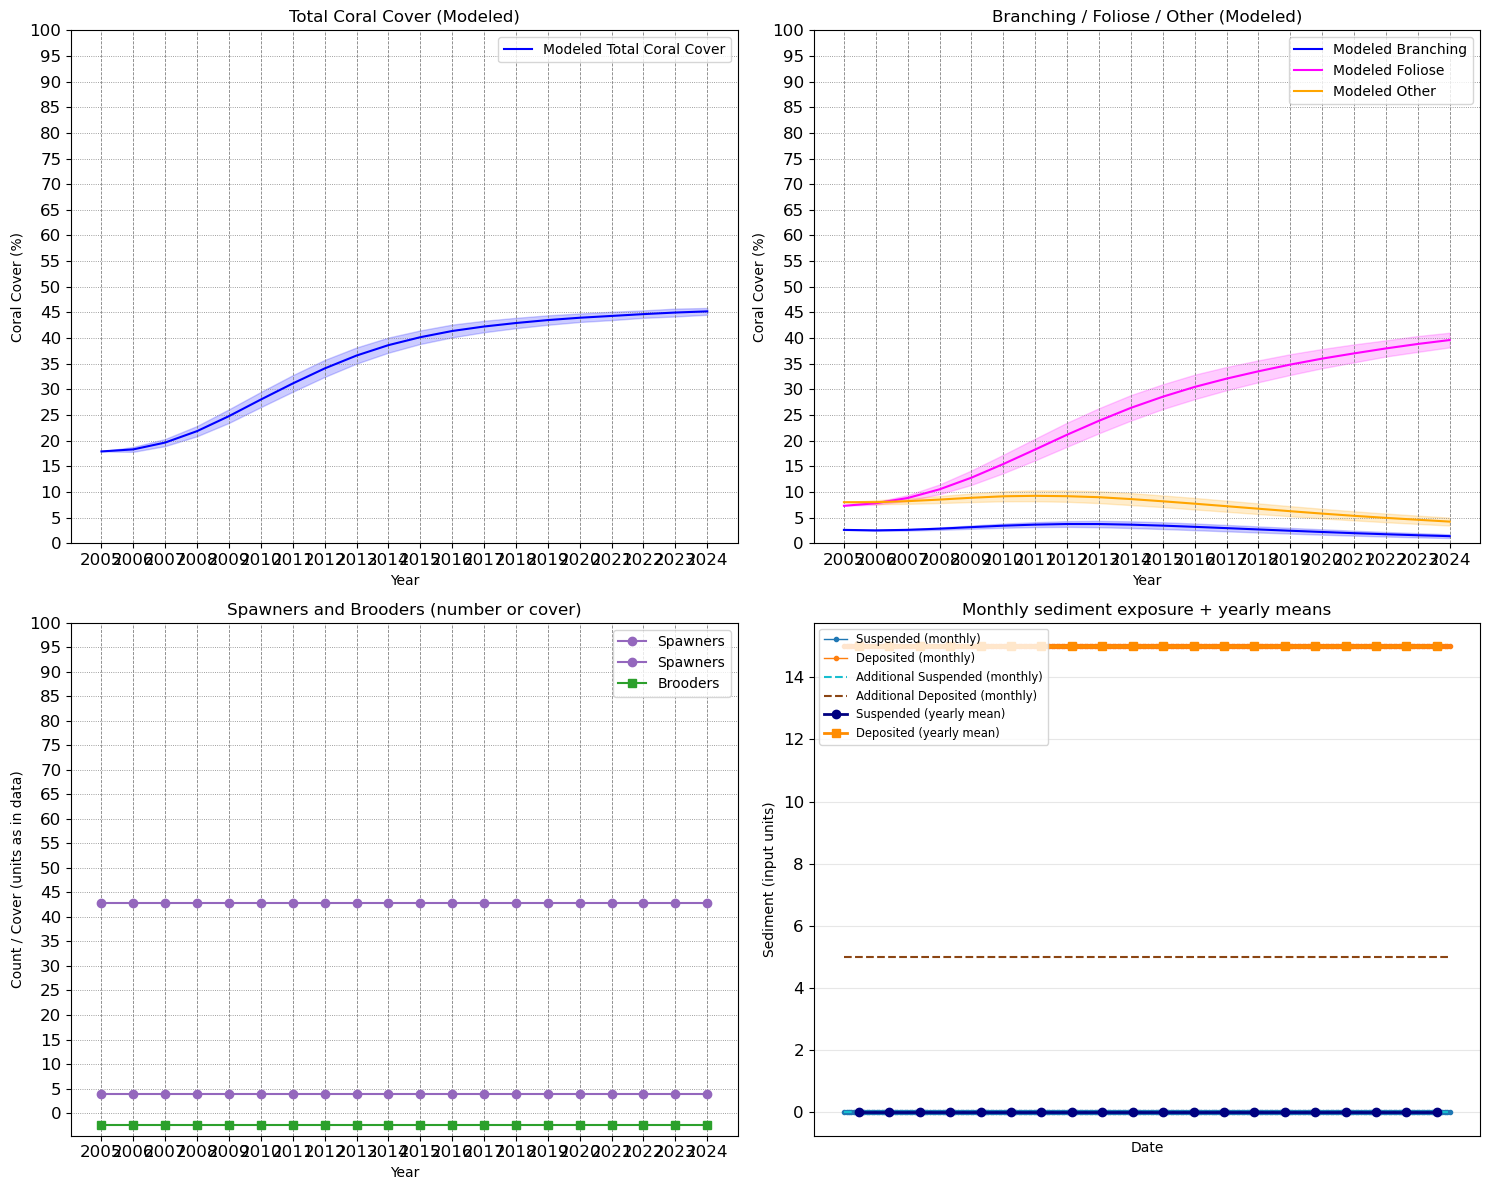

In [42]:
# 
# Create a figure with 2x2 subplots (MODELED ONLY + spawners/brooders + monthly sediment)
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

years = average_branching.index
# Convert model years to actual years for plotting:
actual_years = [int(year + year_start) for year in years]

# Print yearly guidelines (console)
for yy in actual_years:
    print(f"x= {yy}")

# Common x ticks and vertical guidelines
for ax in axs.flat:
    ax.set_xticks(actual_years)
    ax.set_xticklabels([f'{int(year)}' for year in actual_years])
    ax.grid(axis='x', which='major', linestyle='--', color='gray', linewidth=0.6)

# --- Plot 1: Total Coral Cover (modeled)
axs[0, 0].plot(actual_years, average_total.astype(float), label='Modeled Total Coral Cover', color='blue')
axs[0, 0].fill_between(actual_years,
                       (average_total - std_dev_total).astype(float),
                       (average_total + std_dev_total).astype(float),
                       color='blue', alpha=0.2)
axs[0, 0].set_title('Total Coral Cover (Modeled)')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('Coral Cover (%)')
axs[0, 0].legend()
axs[0, 0].set_ylim(0, 100)

# --- Plot 2: Branching / Foliose / Other (modeled)
axs[0, 1].plot(actual_years, average_branching.astype(float), label='Modeled Branching', color='blue')
axs[0, 1].fill_between(actual_years,
                       (average_branching - std_dev_branching).astype(float),
                       (average_branching + std_dev_branching).astype(float),
                       color='blue', alpha=0.2)
axs[0, 1].plot(actual_years, average_foliose.astype(float), label='Modeled Foliose', color='fuchsia')
axs[0, 1].fill_between(actual_years,
                       (average_foliose - std_dev_foliose).astype(float),
                       (average_foliose + std_dev_foliose).astype(float),
                       color='fuchsia', alpha=0.2)
axs[0, 1].plot(actual_years, average_other.astype(float), label='Modeled Other', color='orange')
axs[0, 1].fill_between(actual_years,
                       (average_other - std_dev_other).astype(float),
                       (average_other + std_dev_other).astype(float),
                       color='orange', alpha=0.2)
axs[0, 1].set_title('Branching / Foliose / Other (Modeled)')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('Coral Cover (%)')
axs[0, 1].legend()
axs[0, 1].set_ylim(0, 100)

# --- Plot 3: Number (or cover) of Spawners and Brooders
# Try to find time series in common places; fall back to constant values in opts if needed
spawner_ts = None
brooder_ts = None

# 1) check final_df for common column names
candidates = {
    'spawner': ['spawner_count', 'spawners', 'Spawner', 'spawner_cover', 'spawner (%)', 'Spawners'],
    'brooder': ['brooder_count', 'brooders', 'Brooder', 'brooder_cover', 'brooder (%)', 'Brooders']
}
for name, cols in candidates.items():
    for col in cols:
        if col in final_df.columns:
            if name == 'spawner':
                spawner_ts = final_df.groupby('Year')[col].mean()
            else:
                brooder_ts = final_df.groupby('Year')[col].mean()
            break

# 2) check opts yearly dataframes if available (common structure: opts.yearly_population_df_list)
if spawner_ts is None and 'yearly_population_df_list' in globals() and getattr(opts, 'yearly_population_df_list', None):
    try:
        # attempt to find columns containing 'spawner' or 'brooder'
        df_try = opts.yearly_population_df_list.copy() if isinstance(opts.yearly_population_df_list, (pd.DataFrame, list)) else None
        if isinstance(df_try, pd.DataFrame):
            for col in df_try.columns:
                if 'spawner' in col.lower():
                    spawner_ts = df_try.groupby('Year')[col].mean()
                if 'brooder' in col.lower():
                    brooder_ts = df_try.groupby('Year')[col].mean()
    except Exception:
        pass

# 3) fallback to constants from opts (initial covers) repeated for each year
if spawner_ts is None:
    spawner_val = getattr(opts, 'spawner_cover', None)
    if spawner_val is None:
        spawner_val = 0
    spawner_ts = pd.Series([spawner_val] * len(actual_years), index=years)

if brooder_ts is None:
    brooder_val = getattr(opts, 'brooder_cover', None)
    if brooder_val is None:
        brooder_val = 0
    brooder_ts = pd.Series([brooder_val] * len(actual_years), index=years)

# Convert indices to actual years for plotting (ensure alignment)
spawner_y = [spawner_ts.get(y, spawner_ts.iloc[i]) if y in spawner_ts.index or i < len(spawner_ts) else 0
             for i, y in enumerate(years)]
brooder_y = [brooder_ts.get(y, brooder_ts.iloc[i]) if y in brooder_ts.index or i < len(brooder_ts) else 0
             for i, y in enumerate(years)]

axs[1, 0].plot(actual_years, spawner_y, label='Spawners', color='tab:purple', marker='o')
axs[1, 0].plot(actual_years, brooder_y, label='Brooders', color='tab:green', marker='s')
axs[1, 0].set_title('Spawners and Brooders (number or cover)')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('Count / Cover (units as in data)')
axs[1, 0].legend()
axs[1, 0].grid(axis='y', linestyle=':', color='gray', linewidth=0.6)

# --- Plot 4: Monthly suspended/deposited + additional + yearly averages
# Build monthly dataframe (robust to variable names)
sedi_dict = globals().get('sedi_years', None) or globals().get('additional_sediment_exposure', None) or {}
baseline_suspended = globals().get('baseline_suspended_sediment', 0)
baseline_deposited = globals().get('baseline_deposited_sediment', 0)

# If monthly dict is keyed by (year_rel, month) or by (year, month)
rows = []
if isinstance(sedi_dict, dict) and sedi_dict:
    for k, vals in sedi_dict.items():
        try:
            # accept keys like (rel_year, month) or string 'YYYY-MM' or int-year keyed yearly tuples
            if isinstance(k, tuple) and len(k) >= 2:
                rel_year, month = int(k[0]), int(k[1])
            elif isinstance(k, str) and '-' in k:
                parts = k.split('-')
                rel_year, month = int(parts[0]) - int(year_start) if len(parts[0]) == 4 else int(parts[0]), int(parts[1])
            else:
                # assume key is relative year and vals contains per-month list/dict
                rel_year, month = int(k), 1
            suspended, deposited = (vals if isinstance(vals, (list, tuple)) and len(vals) >= 2 else (vals.get('suspended', 0) if isinstance(vals, dict) else 0, vals.get('deposited', 0) if isinstance(vals, dict) else 0))
        except Exception:
            suspended, deposited = (0, 0)
        year_actual = int(rel_year + year_start)
        try:
            date = pd.Timestamp(year_actual, month, 1)
        except Exception:
            date = pd.Timestamp(year_actual, 1, 1)
        add_s = max(0.0, suspended - baseline_suspended)
        add_d = max(0.0, deposited - baseline_deposited)
        rows.append({"date": date, "Year": year_actual, "Month": int(month), "Suspended": suspended, "Deposited": deposited, "Add_Suspended": add_s, "Add_Deposited": add_d})

# If no monthly dict, try to build from add_sedi_exp_per_year (yearly totals)
if not rows and 'add_sedi_exp_per_year' in globals():
    # add_sedi_exp_per_year: keys are relative model years (0..)
    for rel_year, vals in add_sedi_exp_per_year.items():
        suspended, deposited = (vals if isinstance(vals, (list, tuple)) and len(vals) >= 2 else (0, 0))
        year_actual = int(rel_year + year_start)
        date = pd.Timestamp(year_actual, 1, 1)
        add_s = max(0.0, suspended - baseline_suspended)
        add_d = max(0.0, deposited - baseline_deposited)
        rows.append({"date": date, "Year": year_actual, "Month": 1, "Suspended": suspended, "Deposited": deposited, "Add_Suspended": add_s, "Add_Deposited": add_d})

if not rows:
    axs[1, 1].text(0.5, 0.5, "No sediment monthly data available", ha='center', va='center')
    axs[1, 1].set_title("Sediment (monthly)")
    axs[1, 1].set_xlabel('Date')
    axs[1, 1].set_ylabel('Sediment')
else:
    df_sedi = pd.DataFrame(rows).sort_values("date").set_index("date")
    ax = axs[1, 1]
    # Monthly series
    ax.plot(df_sedi.index, df_sedi["Suspended"], label="Suspended (monthly)", color="tab:blue", marker='.', linewidth=1)
    ax.plot(df_sedi.index, df_sedi["Deposited"], label="Deposited (monthly)", color="tab:orange", marker='.', linewidth=1)
    ax.plot(df_sedi.index, df_sedi["Add_Suspended"], label="Additional Suspended (monthly)", color="tab:cyan", linestyle='--')
    ax.plot(df_sedi.index, df_sedi["Add_Deposited"], label="Additional Deposited (monthly)", color="saddlebrown", linestyle='--')

    # Yearly averages (mean of months within each year)
    yearly_mean = df_sedi.reset_index().groupby("Year")[["Suspended", "Deposited", "Add_Suspended", "Add_Deposited"]].mean()
    # plot yearly means as larger markers at mid-year
    mid_dates = [pd.Timestamp(int(y), 7, 1) for y in yearly_mean.index]
    ax.plot(mid_dates, yearly_mean["Suspended"], label="Suspended (yearly mean)", color="navy", marker='o', linewidth=2)
    ax.plot(mid_dates, yearly_mean["Deposited"], label="Deposited (yearly mean)", color="darkorange", marker='s', linewidth=2)

    ax.set_title("Monthly sediment exposure + yearly means")
    ax.set_xlabel("Date")
    ax.set_ylabel("Sediment (input units)")
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(alpha=0.3)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

# Y-axis guidelines
import numpy as np, math
y_ticks_pct = np.arange(0, 101, 5)
for ax in (axs[0,0], axs[0,1], axs[1,0]):
    ax.set_yticks(y_ticks_pct)
    ax.grid(axis='y', which='major', linestyle=':', color='gray', linewidth=0.6)

# Rugosity ticks
ymin, ymax = axs[0,0].get_ylim()  # reuse a plot to determine sensible ylim for rugosity grid
upper = max(4.0, math.ceil(ymax / 0.5) * 0.5)
rug_ticks = np.arange(0.0, upper + 1e-9, 0.5)
# apply to any rugosity plot among axs (we don't assume fixed position)
for ax in axs.flat:
    if 'Rugosity' in (ax.get_title() or ''):
        ax.set_yticks(rug_ticks)
        ax.grid(axis='y', which='major', linestyle=':', color='gray', linewidth=0.6)

plt.tight_layout()
graph_dir = r'output/figures'
os.makedirs(graph_dir, exist_ok=True)
graph_path = os.path.join(graph_dir, 'combined_graphs_modeled_extended.png')
plt.savefig(graph_path, dpi=200)
plt.show()
#

In [43]:
import winsound
winsound.Beep(1000, 2000)  # 1000 Hz for 200 ms